# Numbered Data Analysis For Weekly 1.5% Strategy

This notebook implements the approved `B_Data_Analysis/Analysis_Plan.md` workflow only. It studies daily entry opportunities that may reach a `+1.5%` target within 5 trading sessions while using a simple `-1.5%` stop rule. No prediction model is trained here.


## 0. Investment Objective And Analysis Rules

- Target return: `+1.5%`.
- Holding period: 5 trading sessions.
- Entry mode: daily entries at `Open[t]`.
- Risk profile: low risk with a fixed `-1.5%` stop.
- Primary label: `target_before_stop_5d`.


<!-- beginner-explanation -->
**How to read this setup cell**

- This cell prepares the notebook before any finance calculation starts.
- It finds the project folders, imports the needed libraries, and creates the output folder for charts and CSV summaries.
- **Target return = 1.50%** means the analysis looks for a move from, for example, **$100.00** to **$101.50**.
- **Stop loss = -1.50%** means the simple risk line is **$98.50** if the entry price is **$100.00**.
- **Horizon = 5 trading sessions** means five stock-market trading days, not five calendar days.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "A_Data_Gathering").exists() and (candidate / "B_Data_Analysis").exists():
        PROJECT_ROOT = candidate
        break
    nested = candidate / "NN_Trading_project"
    if (nested / "A_Data_Gathering").exists() and (nested / "B_Data_Analysis").exists():
        PROJECT_ROOT = nested
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from B_Data_Analysis.helpers.strategy_analysis import (
    FEATURE_COLUMNS,
    HORIZON_SESSIONS,
    OUTCOME_COLUMNS,
    STOP_LOSS,
    TARGET_RETURN,
    breakout_summary,
    build_analysis_table,
    data_quality_report,
    default_paths,
    feature_correlation_matrix,
    feature_label_correlations,
    load_sector_map,
    load_stock_data,
    save_bar_chart,
    save_breakout_examples,
    save_grouped_bar_chart,
    save_grouped_scatter_chart,
    save_heatmap,
    save_histogram_grid,
    save_moving_average_examples,
    save_pie_chart,
    save_scatter_chart,
    sector_mapping_frame,
    sector_return_matrix,
    sector_return_risk_summary,
    stock_return_matrix,
    ticker_return_risk_summary,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-darkgrid")

paths = default_paths(PROJECT_ROOT)
OUTPUT_DIR = paths["output_dir"]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset dir:  {paths['dataset_dir']}")
print(f"Output dir:   {OUTPUT_DIR}")
print(f"Target:       {TARGET_RETURN:.2%}")
print(f"Stop:         {STOP_LOSS:.2%}")
print(f"Horizon:      {HORIZON_SESSIONS} trading sessions")


Project root: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project
Dataset dir:  /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/A_Data_Gathering/dataset/stocks
Output dir:   /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs
Target:       1.50%
Stop:         -1.50%
Horizon:      5 trading sessions


### 0.1 Primary And Secondary Outcomes

The core analysis table is built once, then reused throughout the notebook. Features are calculated using information available by the entry open; labels use the forward 5-session window.


<!-- beginner-explanation -->
**How to read this objective cell**

- **Analysis rows** are every ticker/date opportunity in the dataset.
- **Valid forward rows** have enough future data to check the full 5-session outcome.
- **Valid backward rows** have enough past data to calculate every feature, such as 20-day return, 50-day moving average, RSI, MACD, and Bollinger Bands.
- **Valid analysis rows** meet both rules: enough past data for features and enough future data for labels.
- **Primary success rate** means price reached the **+1.5%** target before touching the **-1.5%** stop.
- **Raw target-hit rate** only asks whether price reached the target within five sessions; it does not care whether the stop was hit first.
- Early rows often fail the backward-window rule, and the last few rows often fail the forward-window rule.


Loaded tickers: 60
Analysis rows:  19,380
Valid forward rows: 19,140
Valid backward rows: 16,380
Valid analysis rows: 16,140
Primary success rate: 47.66%
Raw target-hit rate:  68.05%
Analysis-ready primary success rate: 47.53%
Analysis-ready raw target-hit rate:  67.95%
Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/objective_target_before_stop_pie.png


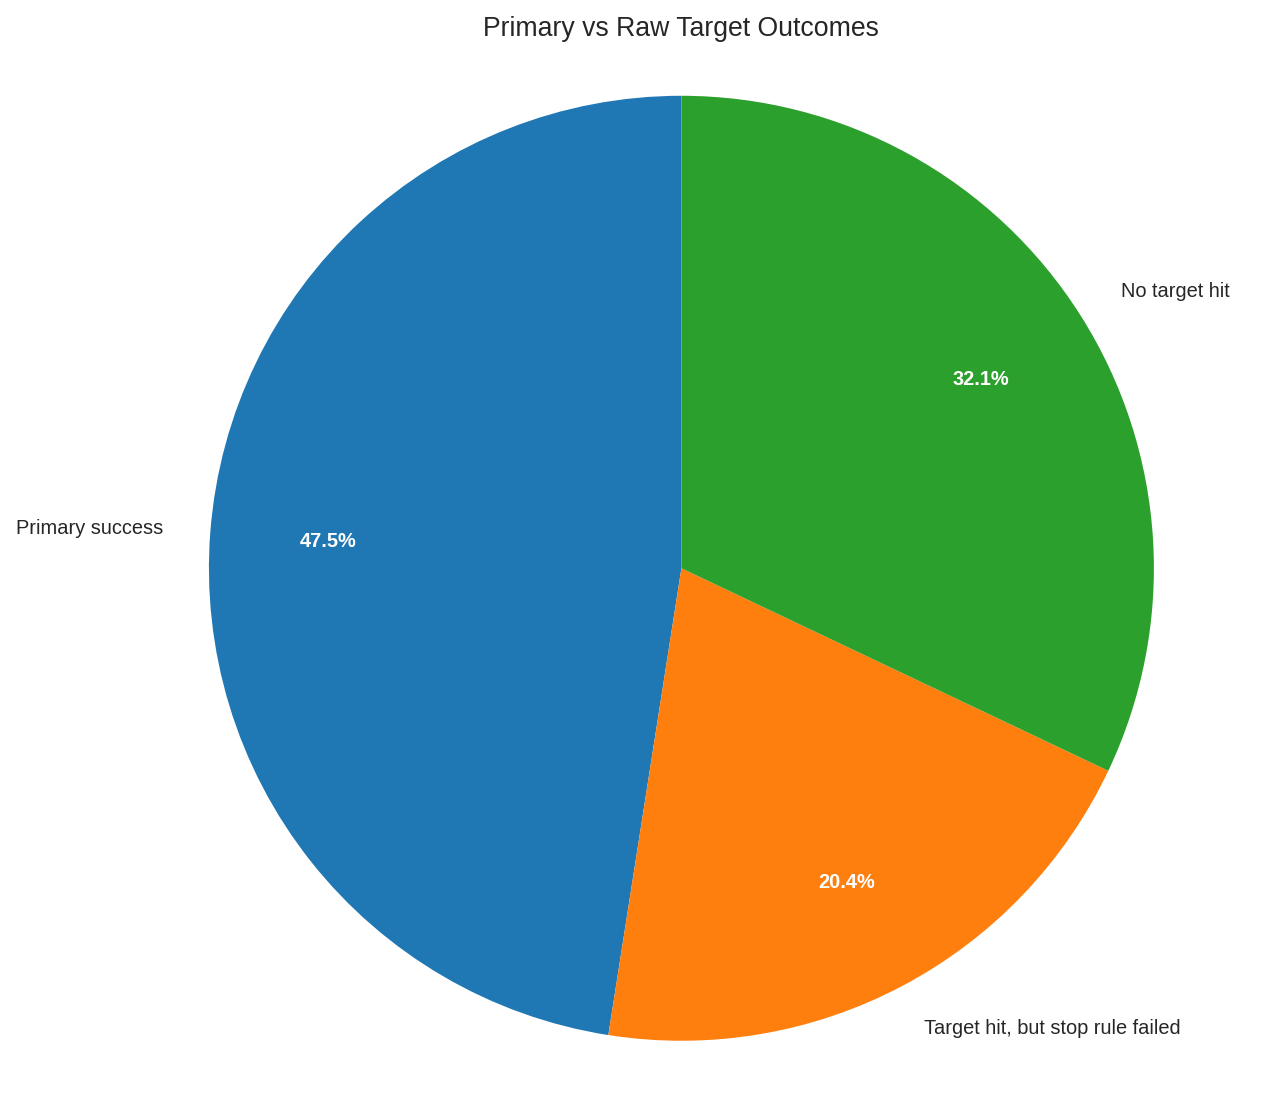

In [2]:
stock_data = load_stock_data(paths["dataset_dir"])
sector_map = load_sector_map(paths["sector_map"])
analysis_table = build_analysis_table(
    stock_data=stock_data,
    sector_map=sector_map,
    target_return=TARGET_RETURN,
    stop_loss=STOP_LOSS,
    horizon_sessions=HORIZON_SESSIONS,
)
valid_rows = analysis_table[analysis_table["valid_forward_window"]].copy()
valid_backward_rows = analysis_table[analysis_table["valid_backward_window"]].copy()
valid_analysis_rows = analysis_table[analysis_table["valid_analysis_window"]].copy()

primary_success_rate = valid_rows["target_before_stop_5d"].mean()
raw_target_hit_rate = valid_rows["target_hit_5d"].mean()
analysis_primary_success_rate = valid_analysis_rows["target_before_stop_5d"].mean()
analysis_raw_target_hit_rate = valid_analysis_rows["target_hit_5d"].mean()

target_hit_but_not_primary = max(analysis_raw_target_hit_rate - analysis_primary_success_rate, 0.0)
no_target_hit = max(1.0 - analysis_raw_target_hit_rate, 0.0)
objective_pie_path = save_pie_chart(
    {
        "Primary success": analysis_primary_success_rate,
        "Target hit, but stop rule failed": target_hit_but_not_primary,
        "No target hit": no_target_hit,
    },
    OUTPUT_DIR / "objective_target_before_stop_pie.png",
    title="Primary vs Raw Target Outcomes",
)

print(f"Loaded tickers: {len(stock_data)}")
print(f"Analysis rows:  {len(analysis_table):,}")
print(f"Valid forward rows: {len(valid_rows):,}")
print(f"Valid backward rows: {len(valid_backward_rows):,}")
print(f"Valid analysis rows: {len(valid_analysis_rows):,}")
print(f"Primary success rate: {primary_success_rate:.2%}")
print(f"Raw target-hit rate:  {raw_target_hit_rate:.2%}")
print(f"Analysis-ready primary success rate: {analysis_primary_success_rate:.2%}")
print(f"Analysis-ready raw target-hit rate:  {analysis_raw_target_hit_rate:.2%}")
print(f"Saved: {objective_pie_path}")
display(Image(filename=str(objective_pie_path)))


## 1. Exploratory Data Analysis (EDA)

### 1.1 Dataset Overview


<!-- beginner-explanation -->
**How to read this dataset overview**

- A **ticker** is the trading symbol for a stock, such as **AGCO**.
- A **row** is one daily price record for one ticker.
- **OHLCV** means **Open**, **High**, **Low**, **Close**, and **Volume**.
- **Open** is the first traded price of the day; **Close** is the final traded price of the day.
- **High** and **Low** are the day's price range.
- **Volume** is how many shares traded.
- **Adj Close** accounts for corporate actions such as splits and dividends.
- Use this cell as the basic inventory before trusting deeper analysis.


In [3]:
overview_rows = []
for ticker, df in stock_data.items():
    overview_rows.append({
        "Ticker": ticker,
        "Rows": len(df),
        "Start": df.index.min().date(),
        "End": df.index.max().date(),
        "Columns": ", ".join(df.columns),
    })

overview_df = pd.DataFrame(overview_rows).sort_values("Ticker")
overview_df.to_csv(OUTPUT_DIR / "dataset_overview.csv", index=False)

print(f"Tickers: {len(overview_df)}")
print(f"Total rows: {overview_df['Rows'].sum():,}")
print(f"Overall date range: {overview_df['Start'].min()} to {overview_df['End'].max()}")
display(overview_df.head(10))


Tickers: 60
Total rows: 19,380
Overall date range: 2025-01-02 to 2026-04-17


,Ticker,Rows,Start,End,Columns
0,AGCO,323,2025-01-02,2026-04-17,"Adj Close, Close, High, Low, Open, Volume"
1,ALLE,323,2025-01-02,2026-04-17,"Adj Close, Close, High, Low, Open, Volume"
2,ALNY,323,2025-01-02,2026-04-17,"Adj Close, Close, High, Low, Open, Volume"
3,AVB,323,2025-01-02,2026-04-17,"Adj Close, Close, High, Low, Open, Volume"
4,BR,323,2025-01-02,2026-04-17,"Adj Close, Close, High, Low, Open, Volume"
5,BURL,323,2025-01-02,2026-04-17,"Adj Close, Close, High, Low, Open, Volume"
6,BWXT,323,2025-01-02,2026-04-17,"Adj Close, Close, High, Low, Open, Volume"
7,CALM,323,2025-01-02,2026-04-17,"Adj Close, Close, High, Low, Open, Volume"
8,CBOE,323,2025-01-02,2026-04-17,"Adj Close, Close, High, Low, Open, Volume"
9,CMI,323,2025-01-02,2026-04-17,"Adj Close, Close, High, Low, Open, Volume"


### 1.2 Data Quality Check


<!-- beginner-explanation -->
**How to read this data quality cell**

- This cell reports whether any ticker has obvious data problems.
- **Tickers with quality issues** is the main result; `0 / 60` means all 60 tickers passed the checks.
- The compact summary table totals the checks across the full dataset instead of listing every ticker.
- **Issue Count** combines missing values, duplicate dates, impossible price ranges, and suspicious open/close values.


In [4]:
quality_df = data_quality_report(stock_data)
quality_df.to_csv(OUTPUT_DIR / "dataset_quality_summary.csv", index=False)

issue_count = int((quality_df["Issue_Count"] > 0).sum())
quality_summary = pd.DataFrame({
    "Total_Tickers": [len(quality_df)],
    "Tickers_With_Issues": [issue_count],
    "Total_Issues": [int(quality_df["Issue_Count"].sum())],
    "Duplicate_Dates": [int(quality_df["Duplicate_Dates"].sum())],
    "Non_Positive_Prices": [int(quality_df["Non_Positive_Prices"].sum())],
    "Price_Range_Issues": [int((
        quality_df["High_Less_Than_Low"]
        + quality_df["Open_Outside_Range"]
        + quality_df["Close_Outside_Range"]
    ).sum())],
    "Missing_Values": [int(quality_df.filter(like="Missing_").sum().sum())],
})

print(f"Tickers with quality issues: {issue_count} / {len(quality_df)}")
display(quality_summary)


Tickers with quality issues: 0 / 60


,Total_Tickers,Tickers_With_Issues,Total_Issues,Duplicate_Dates,Non_Positive_Prices,Price_Range_Issues,Missing_Values
0,60,0,0,0,0,0,0


### 1.3 Ticker And Sector Mapping


<!-- beginner-explanation -->
**How to read this sector mapping cell**

- A **sector** is a broad business category, such as Technology, Healthcare, Financial, or Industrial.
- The count table shows how many tickers belong to each sector and what percent of the ticker universe they represent.
- The pie chart shows the same dataset composition visually.
- If Industrial has the largest slice, many analyzed tickers are industrial companies.
- This matters because strategy results can be biased toward sectors with more tickers.


Sector counts:


,Tickers,Ticker_%
Sector,,
Industrial,19,31.7
Financial,15,25.0
Technology,10,16.7
Consumer,6,10.0
Real Estate,6,10.0
Healthcare,4,6.7


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/sector_counts_pie.png


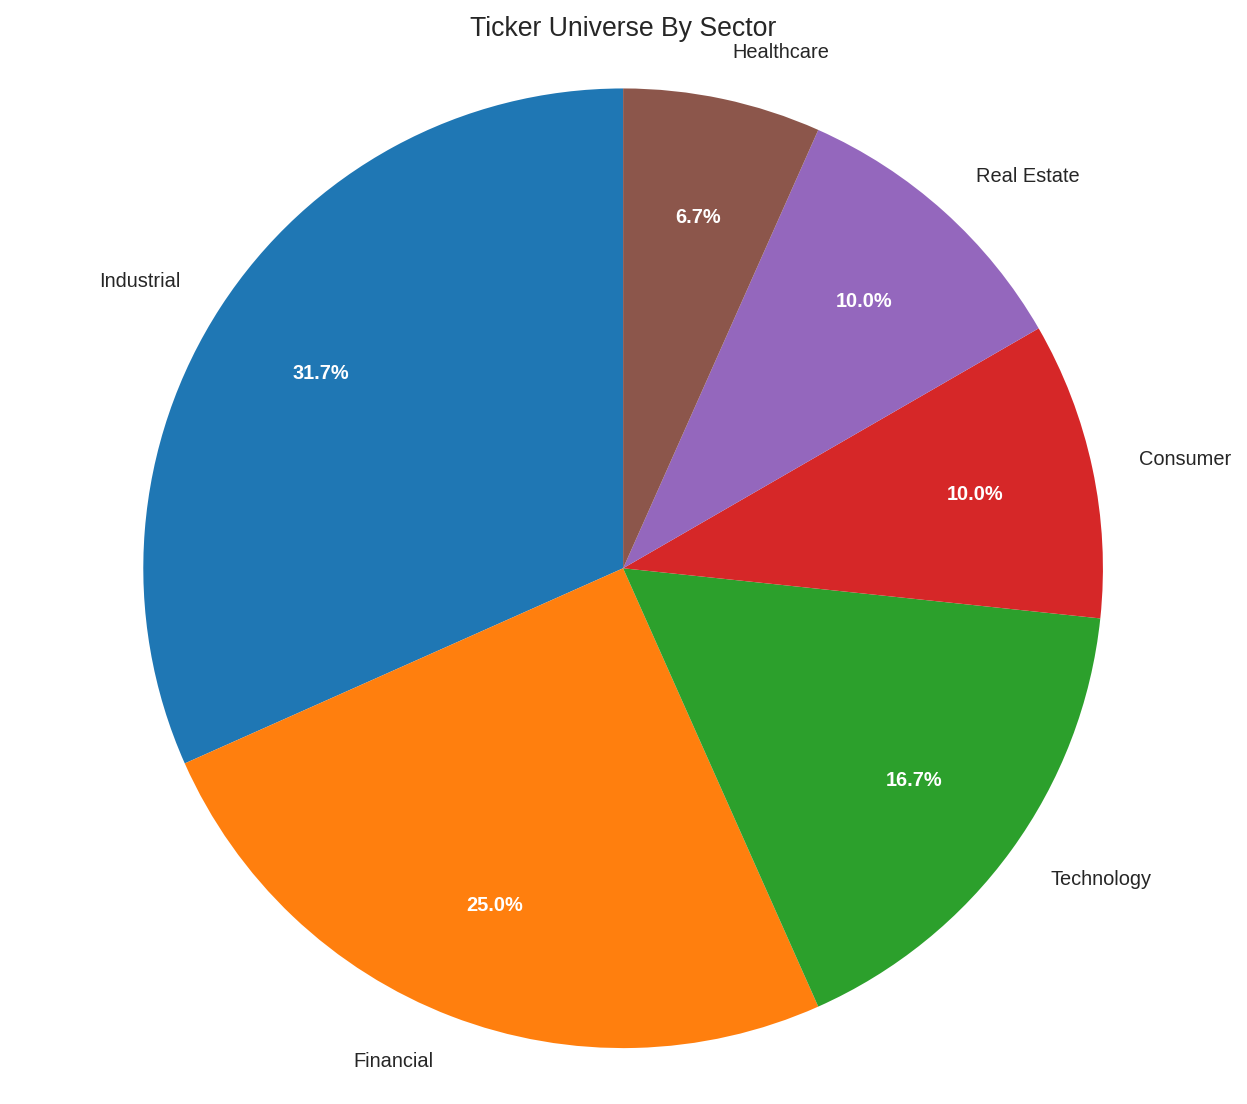

In [5]:
sector_df = sector_mapping_frame(list(stock_data), sector_map)
sector_counts = sector_df.groupby("Sector").agg(Tickers=("Ticker", "count")).sort_values("Tickers", ascending=False)
sector_counts["Ticker_%"] = (sector_counts["Tickers"] / sector_counts["Tickers"].sum() * 100).round(1)
sector_df.to_csv(OUTPUT_DIR / "sector_mapping_summary.csv", index=False)
sector_counts.to_csv(OUTPUT_DIR / "sector_counts.csv")

sector_pie_path = save_pie_chart(
    sector_counts["Tickers"],
    OUTPUT_DIR / "sector_counts_pie.png",
    title="Ticker Universe By Sector",
)

print("Sector counts:")
display(sector_counts)
print(f"Saved: {sector_pie_path}")
display(Image(filename=str(sector_pie_path)))


### 1.4 Simple Return And Risk Statistics

This section intentionally avoids Sharpe, skewness, and kurtosis. It uses simple return, drawdown, and target/stop outcome statistics.


<!-- beginner-explanation -->
**How to read the ticker risk table and charts**

- Each row summarizes one ticker.
- **Total Return** is the full-period price change from first close to last close.
- **Mean Weekly Return** is the average week-by-week return.
- **Weekly Volatility** measures how jumpy weekly returns are; higher values mean larger typical moves.
- **Max Drawdown** is the worst peak-to-trough drop during the dataset.
- **Positive Week Rate** is the percent of weeks that ended positive.
- **Median Max Forward Return 5d** is the typical best upside seen during the next five sessions.
- **Median Min Forward Drawdown 5d** is the typical worst downside seen during the next five sessions.
- In the risk scatter, higher means a better target-before-stop rate, and farther right means a less negative forward drawdown.
- In the sector-cluster chart, tickers are grouped by sector so you can compare winners and weaker names inside each sector cluster.
- Dot color and size show median forward drawdown; larger/darker dots had deeper typical dips.


,Ticker,Sector,Total_Return,Mean_Weekly_Return,Weekly_Volatility,Max_Drawdown,Positive_Week_Rate,Target_Hit_5d_Rate,Target_Before_Stop_5d_Rate,Median_Max_Forward_Return_5d,Median_Min_Forward_Drawdown_5d
55,VRSN,Technology,0.336177,0.004950,0.036176,-0.308811,0.597015,0.677116,0.536050,0.022086,-0.016375
10,DGX,Healthcare,0.291865,0.004158,0.029449,-0.098050,0.567164,0.677116,0.532915,0.023502,-0.017521
27,LOGI,Technology,0.238241,0.004405,0.052513,-0.375880,0.597015,0.670846,0.529781,0.027211,-0.018808
8,CBOE,Financial,0.526878,0.006808,0.027800,-0.103242,0.626866,0.702194,0.529781,0.024251,-0.019616
34,MTB,Financial,0.159337,0.002577,0.034379,-0.224775,0.582090,0.661442,0.529781,0.021202,-0.019305
24,KLAC,Technology,1.813986,0.016796,0.059344,-0.258606,0.626866,0.858934,0.529781,0.042455,-0.027448
1,ALLE,Industrial,0.122327,0.002063,0.032590,-0.224565,0.582090,0.655172,0.526646,0.021093,-0.016632
53,UBSI,Financial,0.195734,0.003066,0.032103,-0.197861,0.552239,0.655172,0.523511,0.023351,-0.018628
32,MLI,Industrial,0.531795,0.006943,0.038726,-0.225751,0.597015,0.746082,0.523511,0.028053,-0.019157
50,SSB,Financial,0.030206,0.001014,0.035666,-0.256069,0.567164,0.699060,0.520376,0.025204,-0.024612


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/ticker_target_vs_drawdown_scatter.png


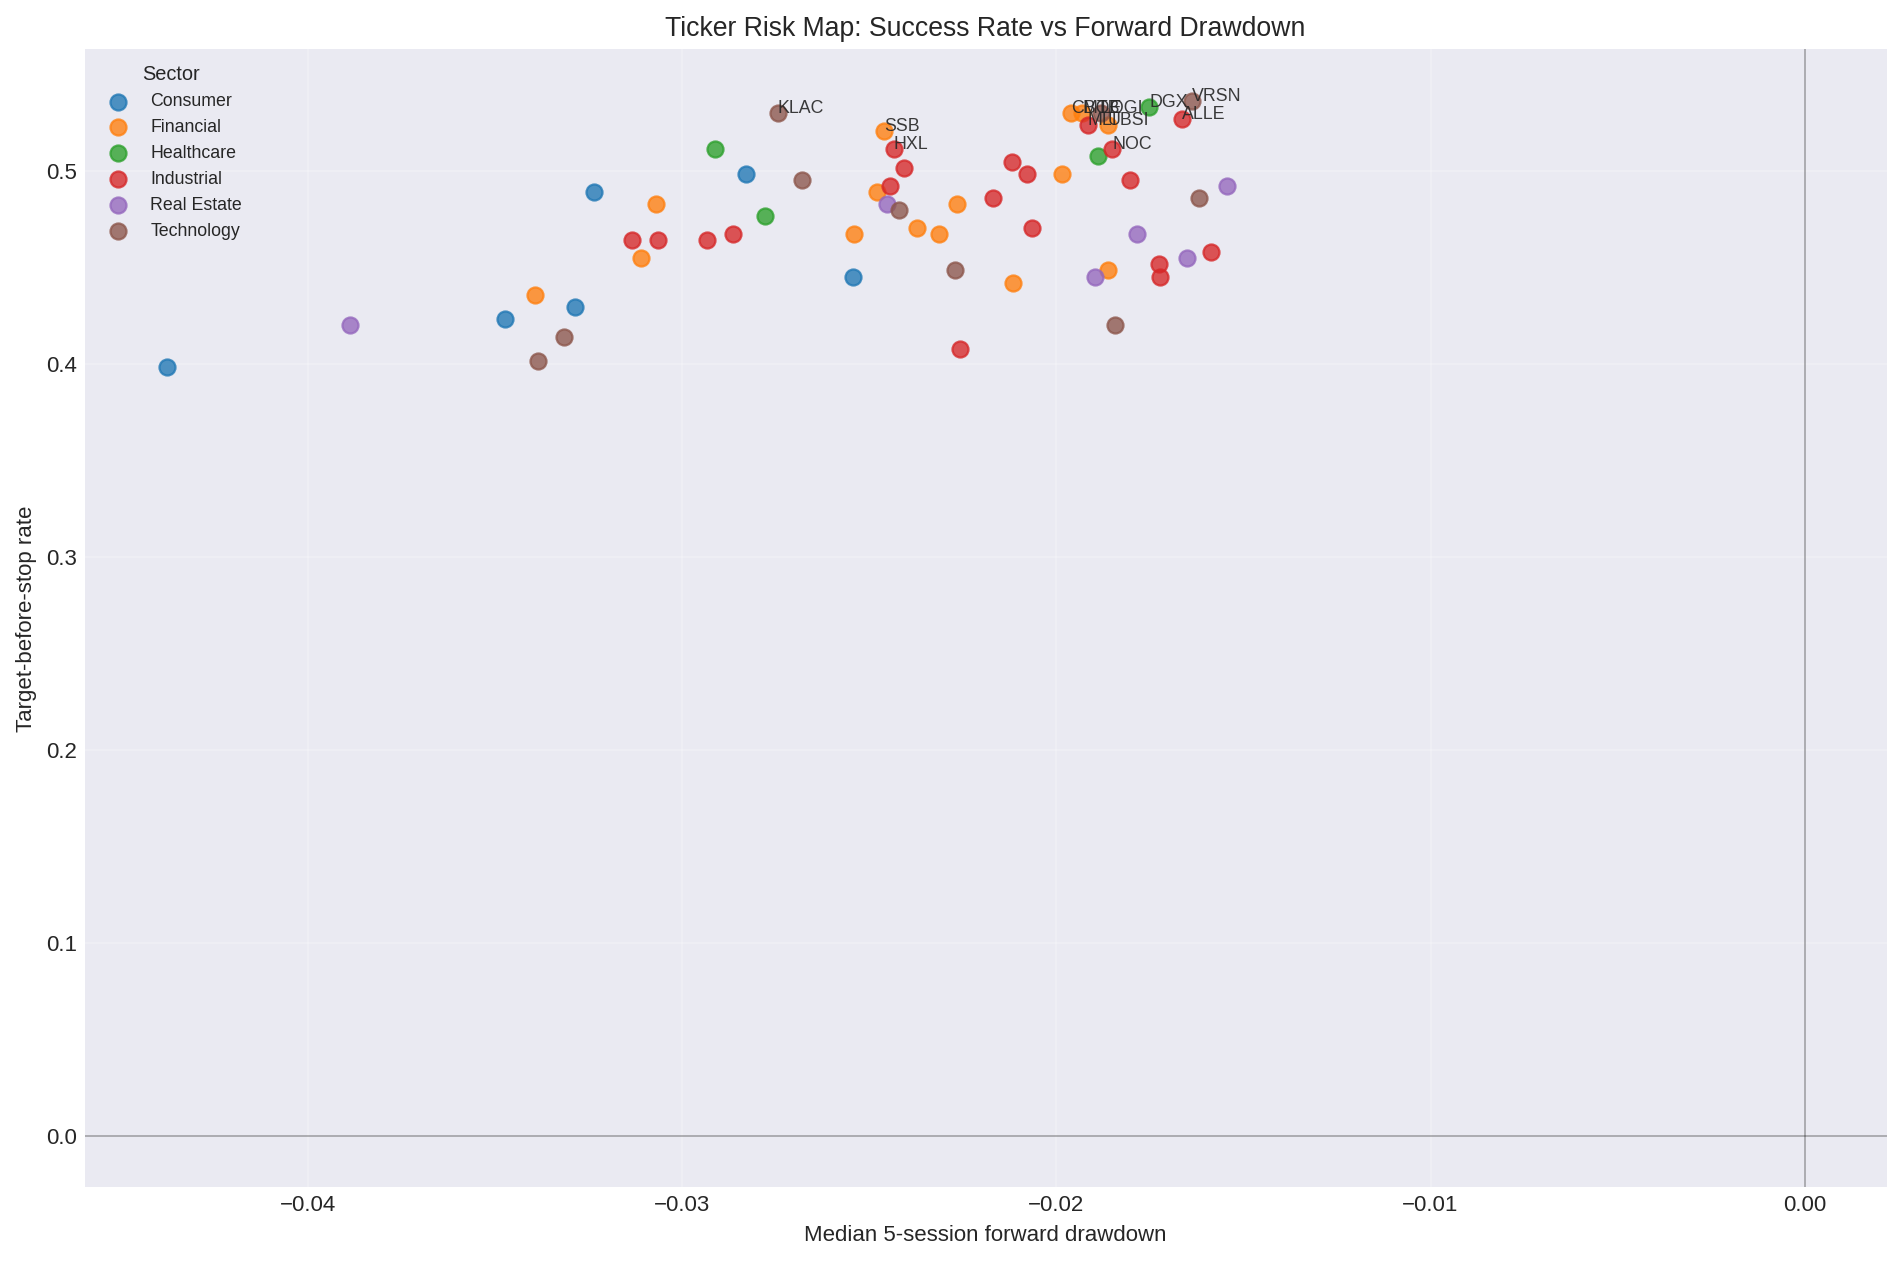

Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/ticker_success_clusters_by_sector.png


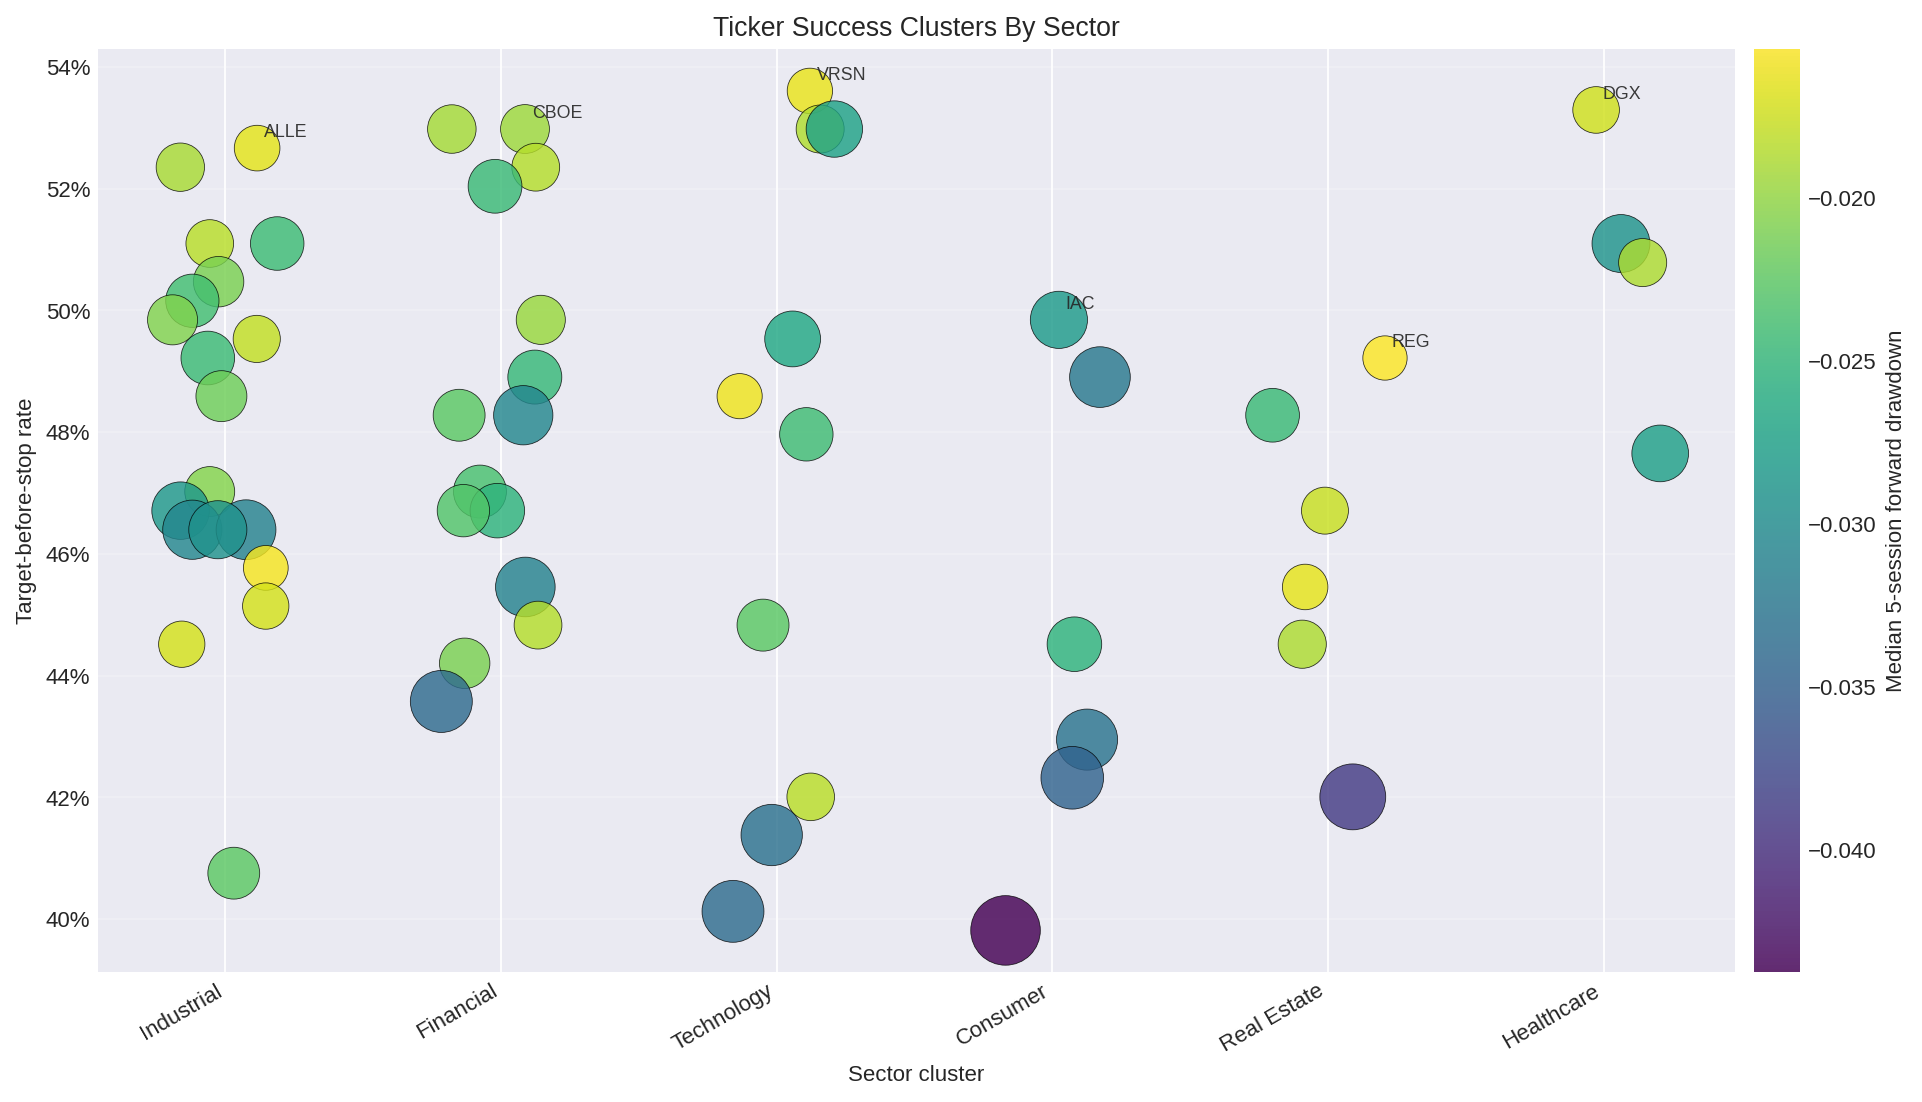

In [6]:
ticker_summary = ticker_return_risk_summary(stock_data, analysis_table, sector_map)
ticker_summary.to_csv(OUTPUT_DIR / "ticker_return_risk_summary.csv", index=False)

cols = [
    "Ticker", "Sector", "Total_Return", "Mean_Weekly_Return", "Weekly_Volatility",
    "Max_Drawdown", "Positive_Week_Rate", "Target_Hit_5d_Rate",
    "Target_Before_Stop_5d_Rate", "Median_Max_Forward_Return_5d",
    "Median_Min_Forward_Drawdown_5d",
]

ticker_risk_reward_path = save_grouped_scatter_chart(
    ticker_summary,
    OUTPUT_DIR / "ticker_target_vs_drawdown_scatter.png",
    x="Median_Min_Forward_Drawdown_5d",
    y="Target_Before_Stop_5d_Rate",
    group_col="Sector",
    label_col="Ticker",
    annotate_top_n=12,
    annotate_by="Target_Before_Stop_5d_Rate",
    title="Ticker Risk Map: Success Rate vs Forward Drawdown",
    xlabel="Median 5-session forward drawdown",
    ylabel="Target-before-stop rate",
    figsize=(12, 8),
)

cluster_plot_data = ticker_summary.dropna(subset=[
    "Sector", "Target_Before_Stop_5d_Rate", "Median_Min_Forward_Drawdown_5d",
]).copy()
sector_order_base = sector_counts.index.tolist() if "sector_counts" in globals() else sorted(cluster_plot_data["Sector"].unique())
sector_order = [sector for sector in sector_order_base if sector in set(cluster_plot_data["Sector"])]
sector_order += [sector for sector in sorted(cluster_plot_data["Sector"].unique()) if sector not in sector_order]
sector_position = {sector: idx for idx, sector in enumerate(sector_order)}
cluster_plot_data["Sector_Position"] = cluster_plot_data["Sector"].map(sector_position)

cluster_rng = np.random.default_rng(42)
cluster_plot_data["Plot_X"] = cluster_plot_data["Sector_Position"] + cluster_rng.uniform(-0.22, 0.22, len(cluster_plot_data))
drawdown_magnitude = cluster_plot_data["Median_Min_Forward_Drawdown_5d"].abs()
max_drawdown_magnitude = drawdown_magnitude.max()
bubble_sizes = 80 + 900 * (drawdown_magnitude / max_drawdown_magnitude if max_drawdown_magnitude > 0 else 0)

fig, ax = plt.subplots(figsize=(13, 7))
cluster_points = ax.scatter(
    cluster_plot_data["Plot_X"],
    cluster_plot_data["Target_Before_Stop_5d_Rate"],
    c=cluster_plot_data["Median_Min_Forward_Drawdown_5d"],
    cmap="viridis",
    s=bubble_sizes,
    alpha=0.82,
    edgecolor="black",
    linewidth=0.35,
)

sector_leaders = (
    cluster_plot_data.sort_values("Target_Before_Stop_5d_Rate", ascending=False)
    .groupby("Sector", sort=False)
    .head(1)
)
for _, row in sector_leaders.iterrows():
    ax.annotate(
        row["Ticker"],
        (row["Plot_X"], row["Target_Before_Stop_5d_Rate"]),
        xytext=(3, 5),
        textcoords="offset points",
        fontsize=8,
        alpha=0.9,
    )

ax.set_xticks(list(sector_position.values()))
ax.set_xticklabels(sector_order, rotation=30, ha="right")
ax.set_xlabel("Sector cluster")
ax.set_ylabel("Target-before-stop rate")
ax.set_title("Ticker Success Clusters By Sector")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.grid(axis="y", alpha=0.25)
ax.margins(x=0.05)
colorbar = fig.colorbar(cluster_points, ax=ax, pad=0.01)
colorbar.set_label("Median 5-session forward drawdown")

sector_cluster_path = OUTPUT_DIR / "ticker_success_clusters_by_sector.png"
fig.tight_layout()
fig.savefig(sector_cluster_path, dpi=160, bbox_inches="tight")
plt.close(fig)

display(ticker_summary[cols].head(15))
print(f"Saved: {ticker_risk_reward_path}")
display(Image(filename=str(ticker_risk_reward_path)))
print(f"Saved: {sector_cluster_path}")
display(Image(filename=str(sector_cluster_path)))


## 2. Technical Analysis

### 2.1 Moving Average Trend View


<!-- beginner-explanation -->
**How to read the moving-average chart**

- A **moving average** smooths price action so the trend is easier to see.
- **SMA 20** is the average close over the last 20 trading days.
- **SMA 50** is the average close over the last 50 trading days.
- **EMA 20** is similar to SMA 20 but gives more weight to recent prices.
- If the close is above the 20-day average, the stock is trading stronger than its recent average.
- Treat this as trend context, not as a buy signal by itself.


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/moving_average_trend_examples.png


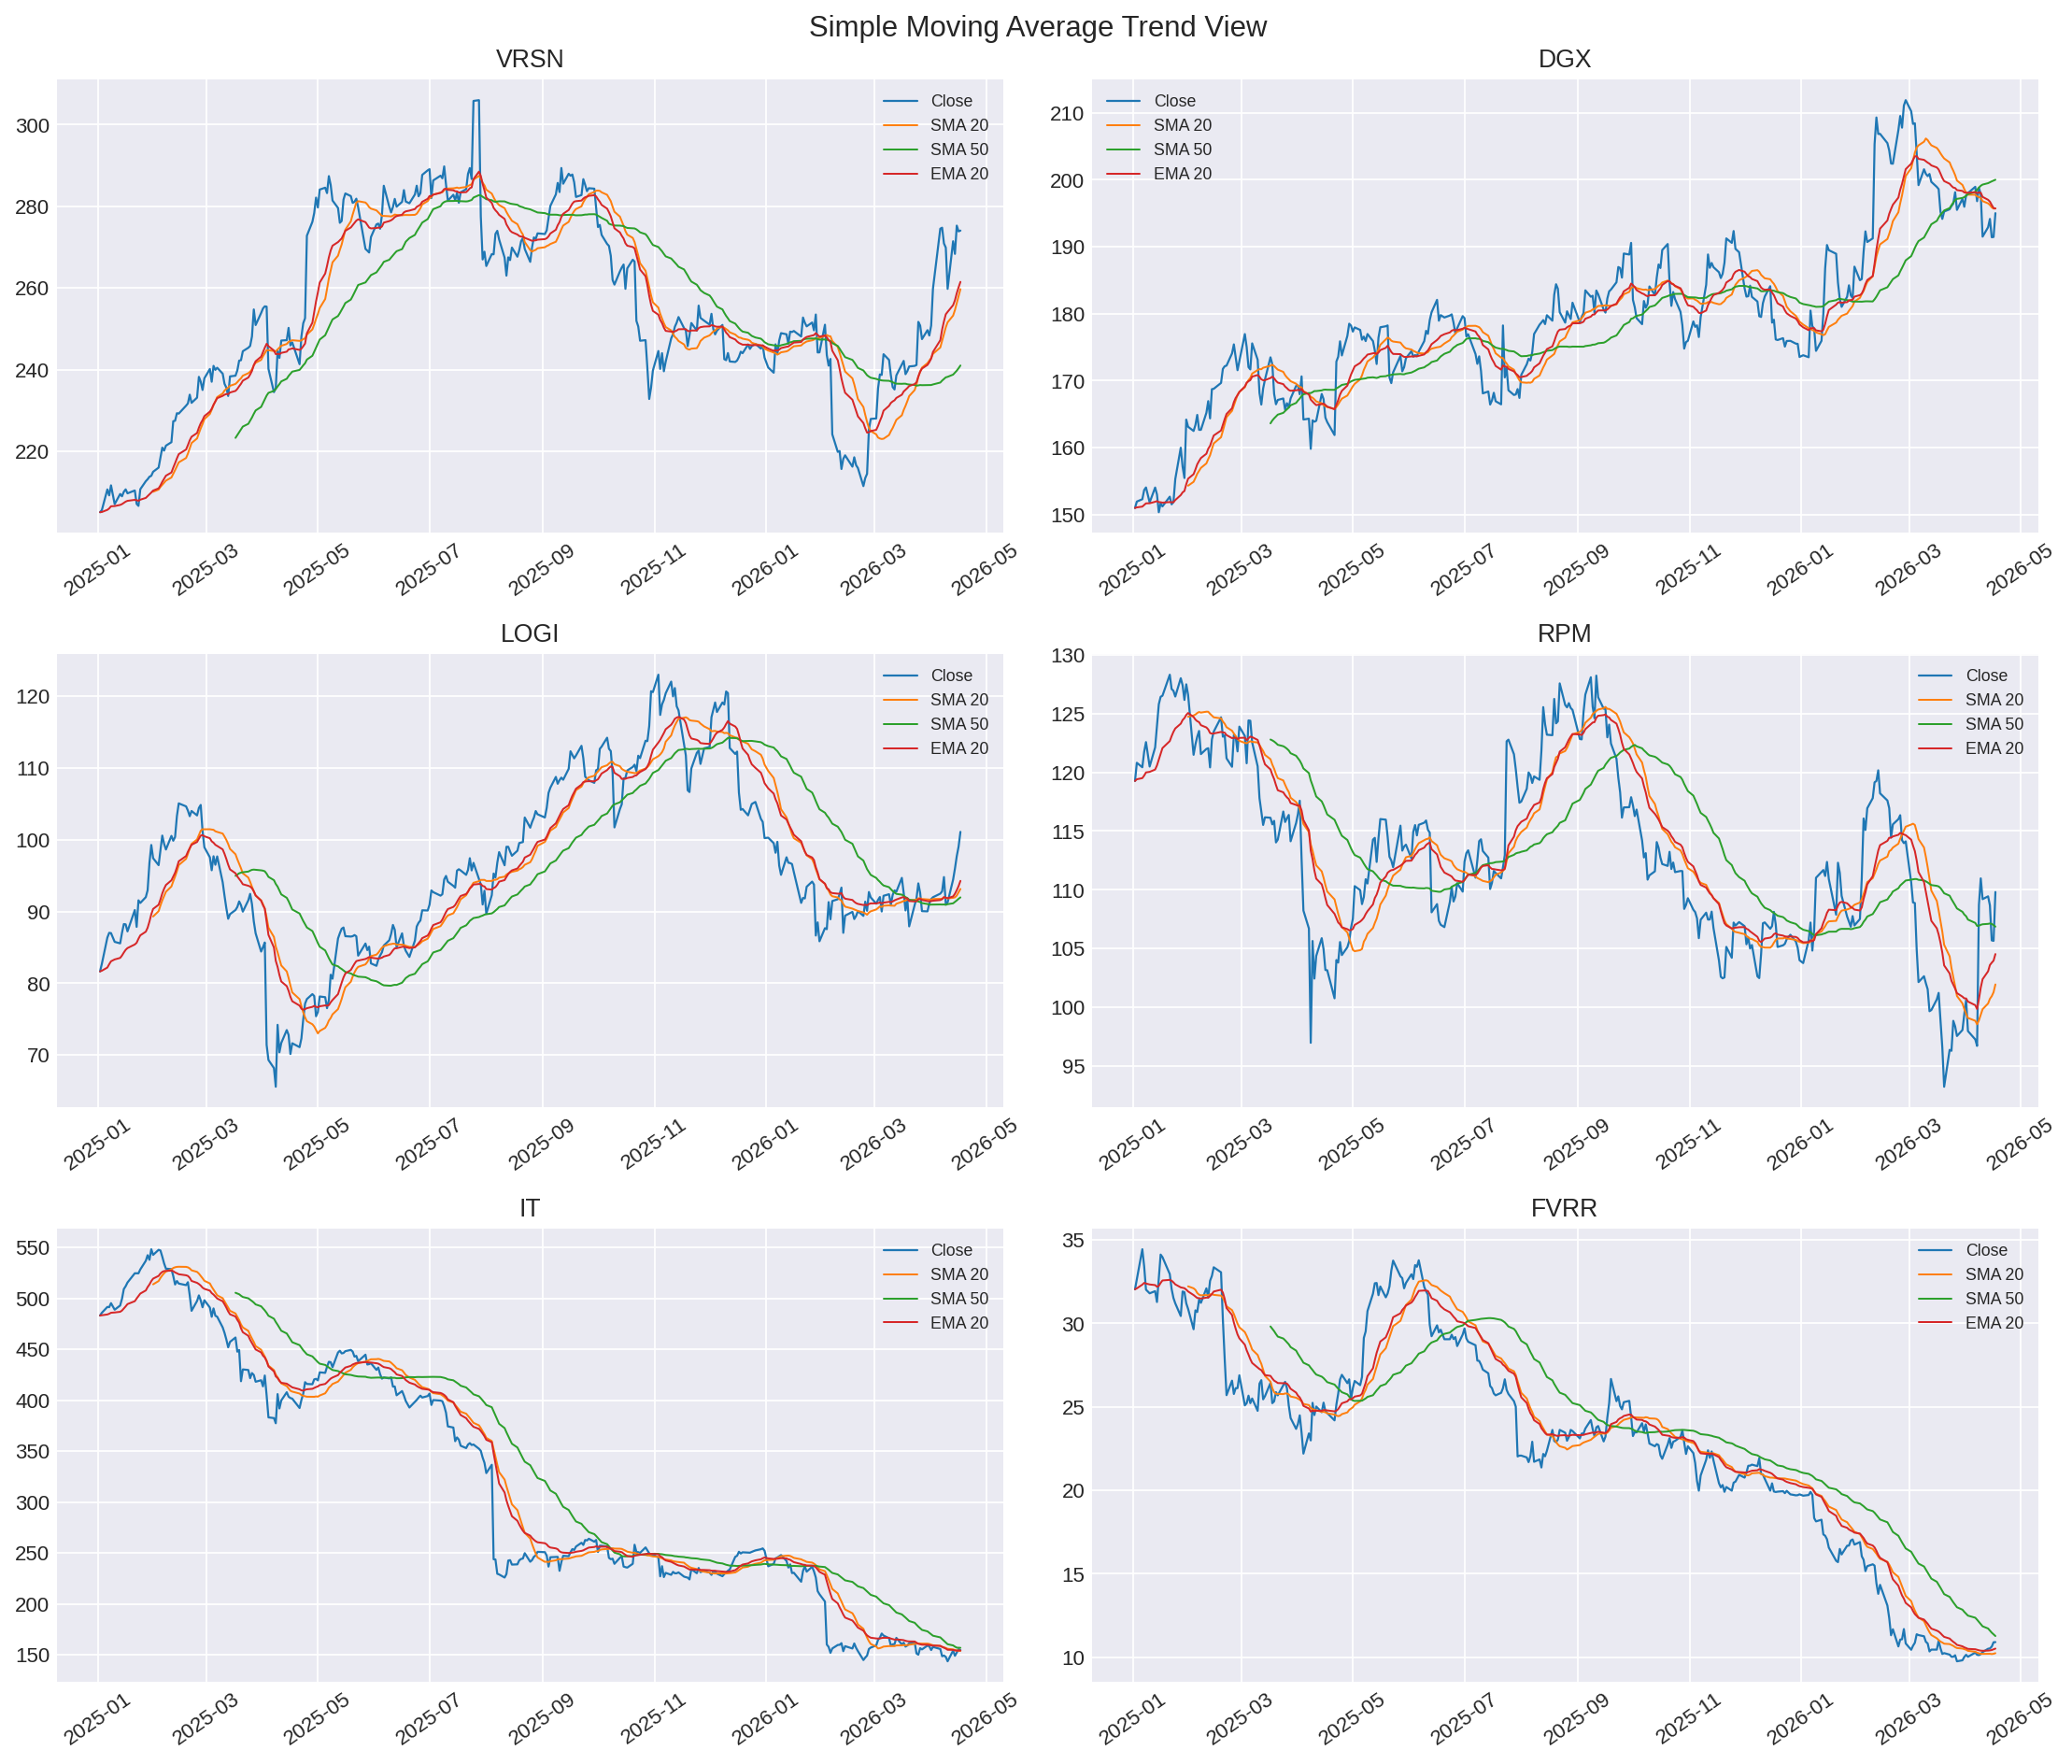

In [7]:
showcase_symbols = pd.concat([
    ticker_summary.head(3)["Ticker"],
    ticker_summary.tail(3)["Ticker"],
]).drop_duplicates().tolist()

ma_path = save_moving_average_examples(
    stock_data=stock_data,
    output_path=OUTPUT_DIR / "moving_average_trend_examples.png",
    symbols=showcase_symbols,
)
print(f"Saved: {ma_path}")
display(Image(filename=str(ma_path)))


### 2.2 Simple Momentum Indicators


<!-- beginner-explanation -->
**How to read the technical indicator summary**

- **RSI 14** is a 0-to-100 momentum indicator.
- A high RSI often means price has risen quickly; a low RSI often means price has fallen quickly.
- **MACD histogram** compares short-term and longer-term momentum.
- **Bollinger Band width** is a volatility-style feature.
- **Bollinger Band position** shows where price sits inside the band.
- **Realized volatility** measures recent historical choppiness.
- **ATR-style range** measures recent daily price range relative to price.
- The histogram chart shows whether each feature is usually low, high, clustered, or spread out.


,count,mean,std,min,25%,50%,75%,max
rsi_14,18480.0,51.574903,12.424660,9.184319,42.780033,51.337592,60.292769,94.848033
macd_hist,17340.0,-0.007587,1.964801,-35.943215,-0.465480,0.003255,0.446323,32.333375
bb_width_20,18180.0,0.126962,0.075130,0.019143,0.074091,0.109167,0.158360,0.790959
bb_position_20,18180.0,0.515180,0.328581,-0.473789,0.253154,0.526331,0.784317,1.500116
dist_open_sma_20,18180.0,0.000772,0.050166,-0.363033,-0.026069,0.001904,0.029756,0.242248
dist_open_ema_20,18180.0,0.000303,0.043294,-0.353350,-0.022470,0.001998,0.025617,0.210421
realized_vol_20,18120.0,0.019060,0.008685,0.004214,0.013139,0.016959,0.022594,0.076328
atr14_norm,18540.0,0.027615,0.010715,0.010202,0.020122,0.025293,0.031880,0.108317


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/technical_indicator_distributions.png


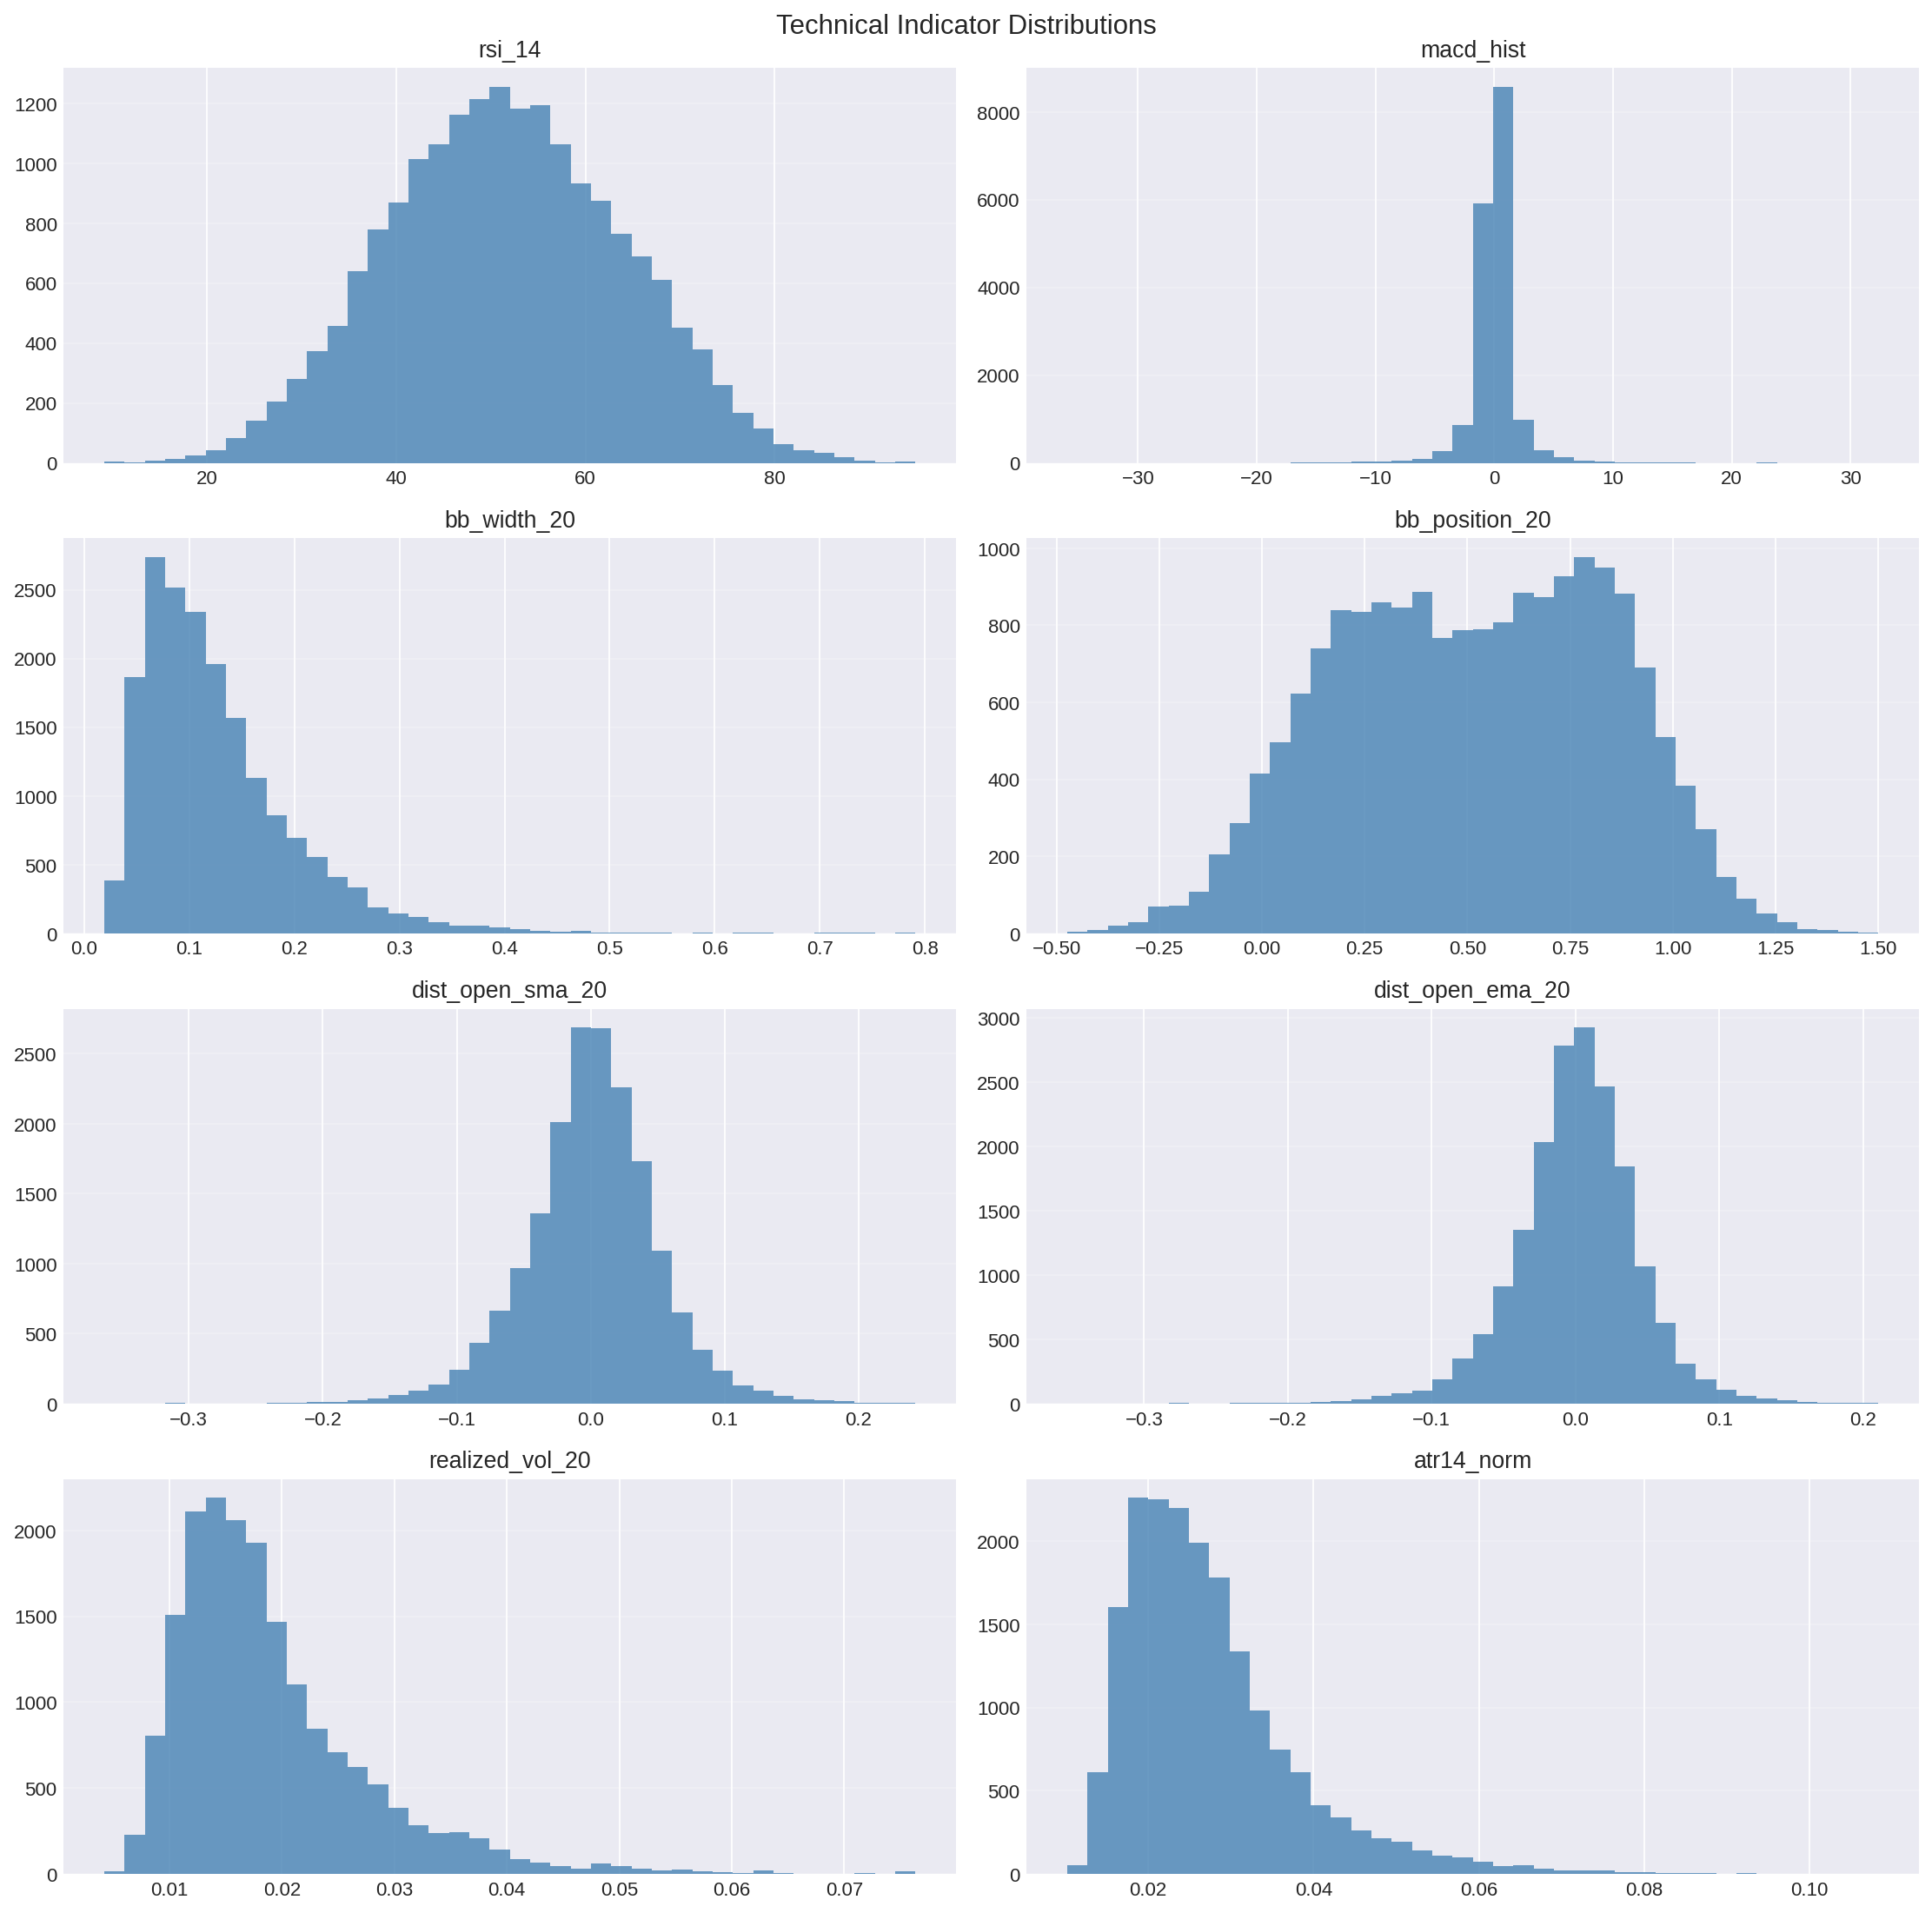

In [8]:
indicator_cols = [
    "rsi_14", "macd_hist", "bb_width_20", "bb_position_20",
    "dist_open_sma_20", "dist_open_ema_20", "realized_vol_20", "atr14_norm",
]
indicator_summary = analysis_table[indicator_cols].describe().T
indicator_summary.to_csv(OUTPUT_DIR / "technical_indicator_summary.csv")

indicator_hist_path = save_histogram_grid(
    analysis_table,
    OUTPUT_DIR / "technical_indicator_distributions.png",
    columns=indicator_cols,
    title="Technical Indicator Distributions",
    bins=40,
    figsize=(14, 14),
)

display(indicator_summary)
print(f"Saved: {indicator_hist_path}")
display(Image(filename=str(indicator_hist_path)))


### 2.3 Simple Breakout Signals


<!-- beginner-explanation -->
**How to read simple breakout signals**

- A **breakout** means price moves above a recent high, such as the prior 20-day high.
- Breakouts can suggest strength or momentum, but they can also fail quickly.
- **Open Breakout 20d Rate** is how often entries opened above the prior 20-day high.
- **Previous Close Breakdown 20d Rate** is how often the previous close was below the prior 20-day low, which is a weakness signal.
- **Target Before Stop 5d Rate** shows whether those sector conditions historically led to the **+1.5% before -1.5%** outcome.


In [9]:
breakout_feature_summary = valid_rows.groupby("Sector").agg(
    Samples=("target_before_stop_5d", "count"),
    Open_Breakout_20d_Rate=("open_above_prior_20d_high", "mean"),
    Prev_Close_Breakdown_20d_Rate=("prev_close_below_prior_20d_low", "mean"),
    Target_Before_Stop_5d_Rate=("target_before_stop_5d", "mean"),
).sort_values("Open_Breakout_20d_Rate", ascending=False)
breakout_feature_summary.to_csv(OUTPUT_DIR / "simple_breakout_feature_summary.csv")
display(breakout_feature_summary)


,Samples,Open_Breakout_20d_Rate,Prev_Close_Breakdown_20d_Rate,Target_Before_Stop_5d_Rate
Sector,,,,
Industrial,6061,0.094843,0.042918,0.481109
Technology,3190,0.073490,0.069463,0.473981
Healthcare,1276,0.072987,0.031040,0.507053
Financial,4785,0.071588,0.053244,0.482759
Consumer,1914,0.055369,0.061521,0.447231
Real Estate,1914,0.041946,0.067673,0.460293


## 3. Market And Sector Analysis

### 3.1 Sector Return And Risk Profile


<!-- beginner-explanation -->
**How to read the sector risk map**

- This cell rolls ticker results up by sector.
- **Weekly Volatility** on the x-axis shows how much weekly returns typically fluctuate in that sector.
- **Target Before Stop 5d Rate** on the y-axis is the stricter success rate.
- Each sector uses a different color, making it easier to match the table and chart.
- A sector near the top-left had a relatively high success rate with lower weekly volatility.
- A sector near the bottom-right is less attractive for a low-risk strategy because it combines lower success with more choppiness.


,Tickers,Avg_Total_Return,Mean_Weekly_Return,Weekly_Volatility,Max_Drawdown,Positive_Week_Rate,Samples,Target_Hit_5d_Rate,Target_Before_Stop_5d_Rate,Median_Forward_Drawdown,P10_Forward_Drawdown
Sector,,,,,,,,,,,
Healthcare,4,0.299240,0.004612,0.042603,-0.241219,0.563433,1276,0.719436,0.507053,-0.022514,-0.065939
Financial,15,0.084957,0.001796,0.041138,-0.273354,0.545274,4785,0.677952,0.482759,-0.023217,-0.068757
Industrial,19,0.373982,0.005018,0.040521,-0.259429,0.553024,6061,0.686685,0.481109,-0.021550,-0.064735
Technology,10,0.118184,0.000451,0.046257,-0.413657,0.525373,3190,0.659561,0.473981,-0.022722,-0.073407
Real Estate,6,-0.142355,-0.002048,0.034253,-0.301854,0.519900,1914,0.623302,0.460293,-0.019990,-0.059929
Consumer,6,-0.089024,-0.001570,0.048964,-0.367524,0.500000,1914,0.733542,0.447231,-0.031792,-0.084737


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/sector_success_vs_volatility_scatter.png


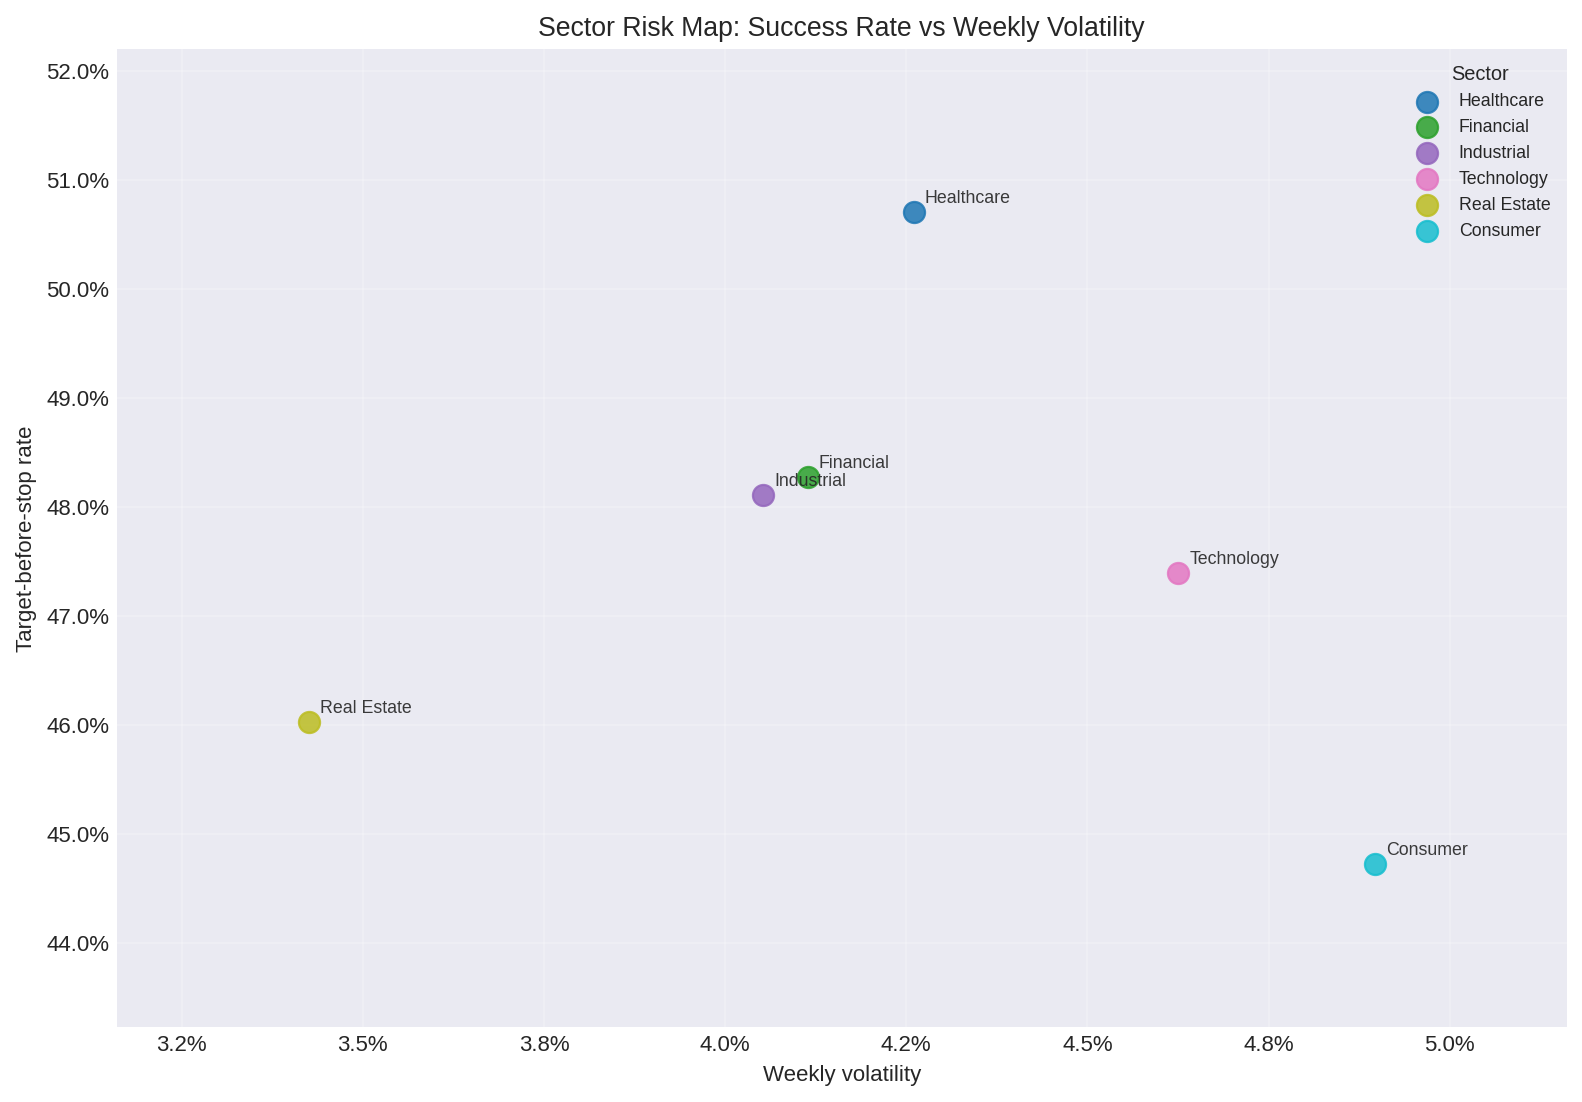

In [10]:
sector_summary = sector_return_risk_summary(ticker_summary, analysis_table)
sector_summary.to_csv(OUTPUT_DIR / "sector_return_risk_summary.csv")

sector_plot = sector_summary.reset_index()
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(sector_plot)))

for color, (_, row) in zip(colors, sector_plot.iterrows()):
    ax.scatter(
        row["Weekly_Volatility"],
        row["Target_Before_Stop_5d_Rate"],
        s=90,
        color=color,
        alpha=0.85,
        label=row["Sector"],
    )
    ax.annotate(
        row["Sector"],
        (row["Weekly_Volatility"], row["Target_Before_Stop_5d_Rate"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
        alpha=0.9,
    )

x_pad = (sector_plot["Weekly_Volatility"].max() - sector_plot["Weekly_Volatility"].min()) * 0.18
x_pad = x_pad if x_pad > 0 else 0.002
y_pad = (sector_plot["Target_Before_Stop_5d_Rate"].max() - sector_plot["Target_Before_Stop_5d_Rate"].min()) * 0.25
y_pad = y_pad if y_pad > 0 else 0.01
ax.set_xlim(sector_plot["Weekly_Volatility"].min() - x_pad, sector_plot["Weekly_Volatility"].max() + x_pad)
ax.set_ylim(sector_plot["Target_Before_Stop_5d_Rate"].min() - y_pad, sector_plot["Target_Before_Stop_5d_Rate"].max() + y_pad)
ax.set_title("Sector Risk Map: Success Rate vs Weekly Volatility")
ax.set_xlabel("Weekly volatility")
ax.set_ylabel("Target-before-stop rate")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))
ax.grid(alpha=0.25)
ax.legend(title="Sector", fontsize=8, title_fontsize=9, loc="best")
fig.tight_layout()
sector_risk_scatter_path = OUTPUT_DIR / "sector_success_vs_volatility_scatter.png"
fig.savefig(sector_risk_scatter_path, dpi=160, bbox_inches="tight")
plt.close(fig)

display(sector_summary)
print(f"Saved: {sector_risk_scatter_path}")
display(Image(filename=str(sector_risk_scatter_path)))


### 3.2 Sector Leaders And Laggards


<!-- beginner-explanation -->
**How to read sector leaders and laggards**

- A **leader** here is not a guaranteed future winner; it simply had stronger historical target-before-stop behavior in this dataset.
- A **laggard** had weaker historical behavior.
- **Tickers** is the number of stocks in that sector.
- **Avg Total Return** is the average full-period return for tickers in that sector.
- **Mean Weekly Return** is the average week-by-week return.
- **Weekly Volatility** shows typical weekly return fluctuation; higher values mean choppier behavior.
- **Max Drawdown** is the average worst peak-to-trough drop for tickers in that sector.
- **Positive Week Rate** is the share of weeks that finished positive.
- **Samples** is the number of valid forward-window entry rows used for the sector outcome rates.
- **Target Hit 5d Rate** is the loose success rate: the target was reached within five sessions.
- **Target Before Stop 5d Rate** is stricter: the target was reached before the stop.
- **Median Forward Drawdown** is the typical worst dip during the next five sessions.
- **P10 Forward Drawdown** is a worse-case-style drawdown level; about 10% of entries were worse than this.
- In the ticker-leader table, **Median Min Forward Drawdown 5d** is the same drawdown idea calculated per ticker.


In [11]:
print("Top sectors by target-before-stop success rate")
display(sector_summary.sort_values("Target_Before_Stop_5d_Rate", ascending=False).head())

print("Weakest sectors by target-before-stop success rate")
display(sector_summary.sort_values("Target_Before_Stop_5d_Rate", ascending=True).head())

leaders_by_sector = (
    ticker_summary.sort_values("Target_Before_Stop_5d_Rate", ascending=False)
    .groupby("Sector")
    .head(3)
    [["Sector", "Ticker", "Target_Before_Stop_5d_Rate", "Median_Min_Forward_Drawdown_5d", "Mean_Weekly_Return"]]
)
leaders_by_sector.to_csv(OUTPUT_DIR / "sector_ticker_leaders.csv", index=False)
display(leaders_by_sector)


Top sectors by target-before-stop success rate


,Tickers,Avg_Total_Return,Mean_Weekly_Return,Weekly_Volatility,Max_Drawdown,Positive_Week_Rate,Samples,Target_Hit_5d_Rate,Target_Before_Stop_5d_Rate,Median_Forward_Drawdown,P10_Forward_Drawdown
Sector,,,,,,,,,,,
Healthcare,4,0.299240,0.004612,0.042603,-0.241219,0.563433,1276,0.719436,0.507053,-0.022514,-0.065939
Financial,15,0.084957,0.001796,0.041138,-0.273354,0.545274,4785,0.677952,0.482759,-0.023217,-0.068757
Industrial,19,0.373982,0.005018,0.040521,-0.259429,0.553024,6061,0.686685,0.481109,-0.021550,-0.064735
Technology,10,0.118184,0.000451,0.046257,-0.413657,0.525373,3190,0.659561,0.473981,-0.022722,-0.073407
Real Estate,6,-0.142355,-0.002048,0.034253,-0.301854,0.519900,1914,0.623302,0.460293,-0.019990,-0.059929


Weakest sectors by target-before-stop success rate


,Tickers,Avg_Total_Return,Mean_Weekly_Return,Weekly_Volatility,Max_Drawdown,Positive_Week_Rate,Samples,Target_Hit_5d_Rate,Target_Before_Stop_5d_Rate,Median_Forward_Drawdown,P10_Forward_Drawdown
Sector,,,,,,,,,,,
Consumer,6,-0.089024,-0.001570,0.048964,-0.367524,0.500000,1914,0.733542,0.447231,-0.031792,-0.084737
Real Estate,6,-0.142355,-0.002048,0.034253,-0.301854,0.519900,1914,0.623302,0.460293,-0.019990,-0.059929
Technology,10,0.118184,0.000451,0.046257,-0.413657,0.525373,3190,0.659561,0.473981,-0.022722,-0.073407
Industrial,19,0.373982,0.005018,0.040521,-0.259429,0.553024,6061,0.686685,0.481109,-0.021550,-0.064735
Financial,15,0.084957,0.001796,0.041138,-0.273354,0.545274,4785,0.677952,0.482759,-0.023217,-0.068757


,Sector,Ticker,Target_Before_Stop_5d_Rate,Median_Min_Forward_Drawdown_5d,Mean_Weekly_Return
55,Technology,VRSN,0.536050,-0.016375,0.004950
10,Healthcare,DGX,0.532915,-0.017521,0.004158
27,Technology,LOGI,0.529781,-0.018808,0.004405
8,Financial,CBOE,0.529781,-0.019616,0.006808
34,Financial,MTB,0.529781,-0.019305,0.002577
24,Technology,KLAC,0.529781,-0.027448,0.016796
1,Industrial,ALLE,0.526646,-0.016632,0.002063
53,Financial,UBSI,0.523511,-0.018628,0.003066
32,Industrial,MLI,0.523511,-0.019157,0.006943
35,Industrial,NOC,0.510972,-0.018504,0.005968


### 3.3 Stock Correlation Matrix


<!-- beginner-explanation -->
**How to read the stock correlation heatmap**

- **Correlation** measures how similarly two stocks move day to day.
- A value near **+1** means they often move in the same direction.
- A value near **0** means their daily moves are not strongly related.
- A value near **-1** means they often move in opposite directions.
- If two bank stocks have high positive correlation, holding both may not diversify risk much because they react to similar market forces.


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/stock_correlation_heatmap.png


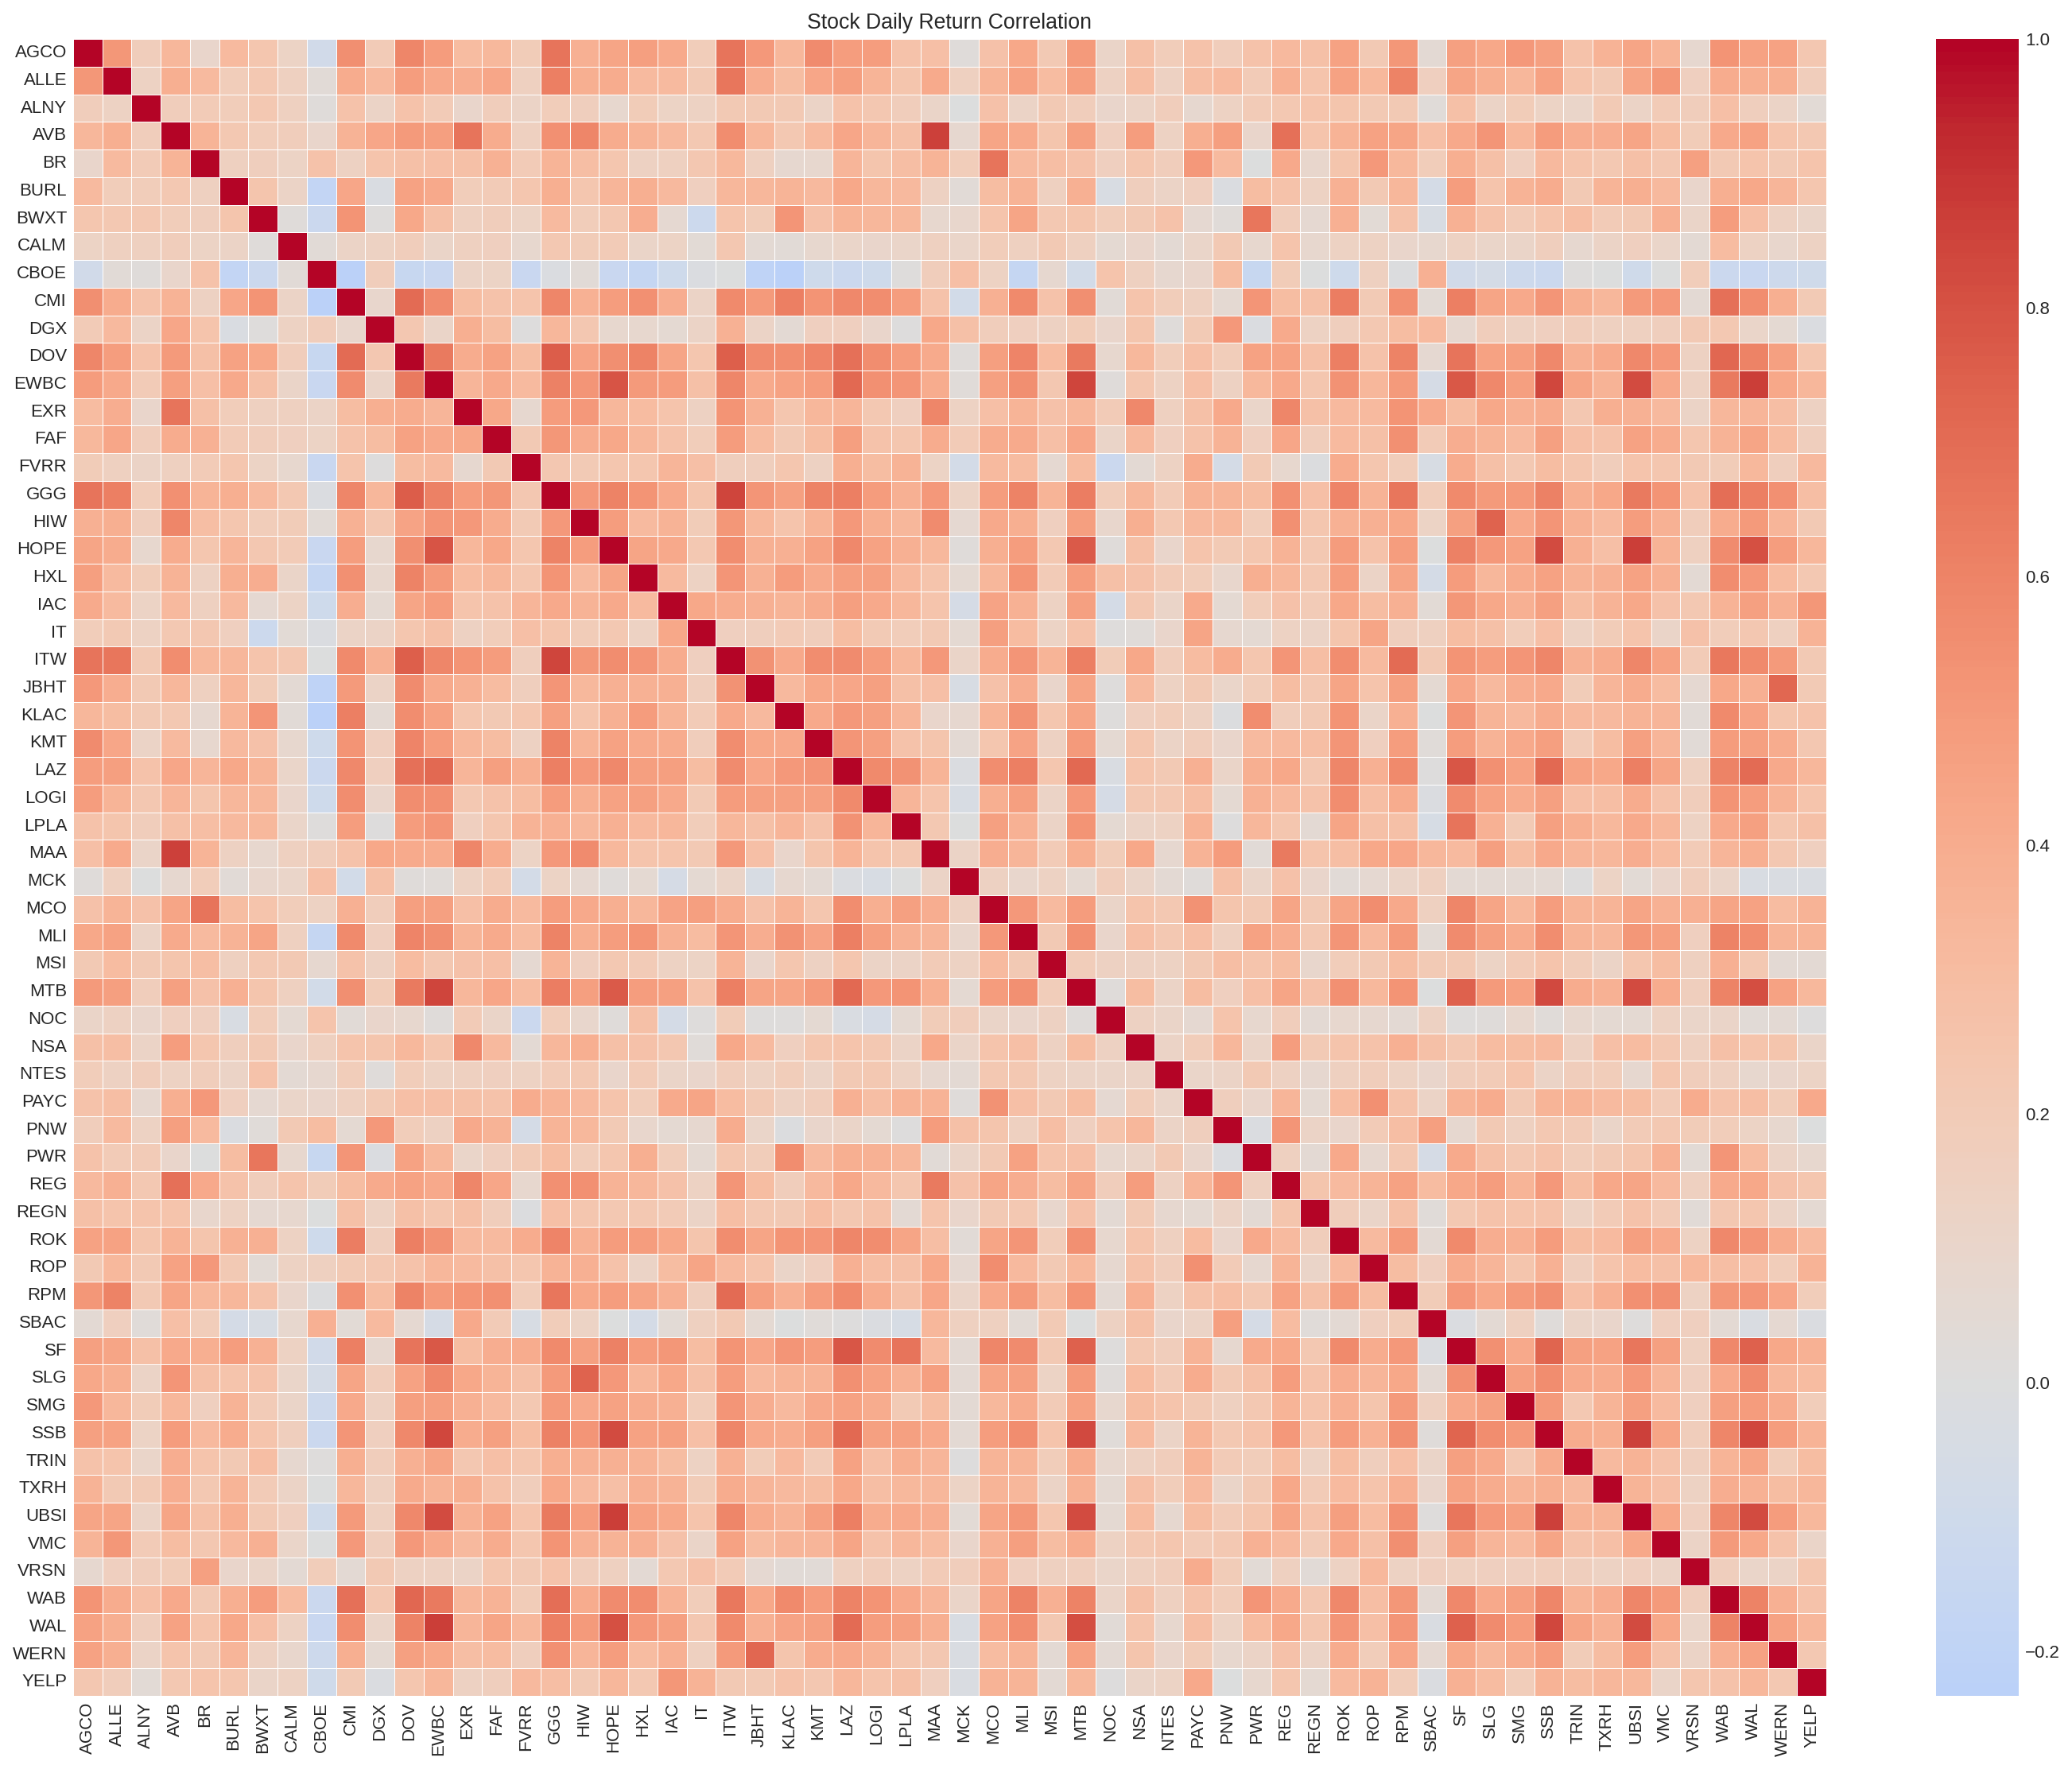

In [12]:
stock_returns = stock_return_matrix(stock_data)
stock_corr = stock_returns.corr()
stock_corr.to_csv(OUTPUT_DIR / "stock_correlation_matrix.csv")

stock_corr_path = save_heatmap(
    stock_corr,
    OUTPUT_DIR / "stock_correlation_heatmap.png",
    title="Stock Daily Return Correlation",
    figsize=(18, 14),
    annot=False,
)
print(f"Saved: {stock_corr_path}")
display(Image(filename=str(stock_corr_path)))


### 3.4 Sector Correlation Matrix


<!-- beginner-explanation -->
**How to read the sector correlation heatmap**

- This is the same idea as stock correlation, but grouped by sector.
- It answers whether sectors tend to move together.
- If Financial and Industrial have high correlation, both may fall together during broad market weakness.
- For a low-risk weekly strategy, lower correlation between chosen sectors can help avoid having every position exposed to the same market move.


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/sector_correlation_heatmap.png


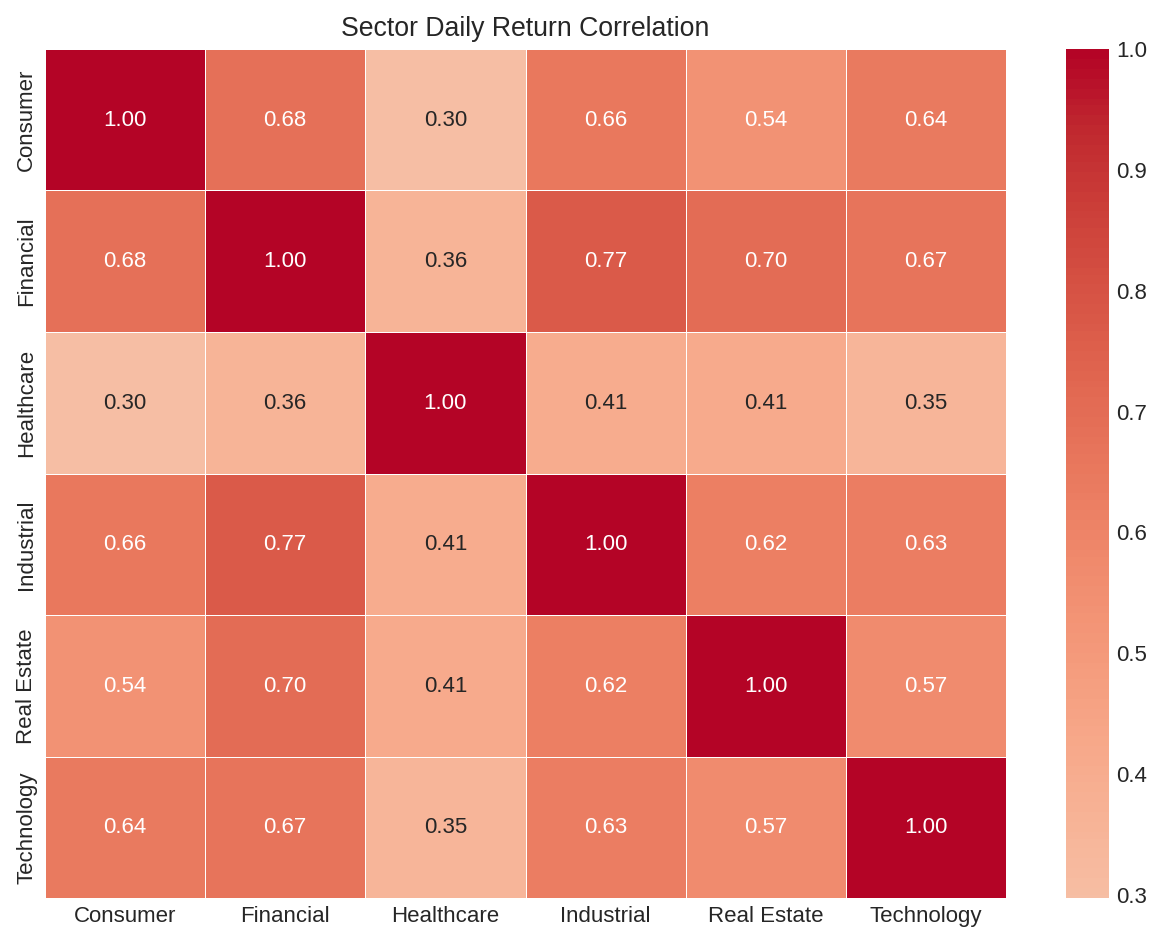

In [13]:
sector_returns = sector_return_matrix(stock_data, sector_map)
sector_corr = sector_returns.corr()
sector_corr.to_csv(OUTPUT_DIR / "sector_correlation_matrix.csv")

sector_corr_path = save_heatmap(
    sector_corr,
    OUTPUT_DIR / "sector_correlation_heatmap.png",
    title="Sector Daily Return Correlation",
    figsize=(8, 6),
    annot=True,
)
print(f"Saved: {sector_corr_path}")
display(Image(filename=str(sector_corr_path)))


## 4. Pattern Recognition

### 4.1 Simple Breakout Pattern Analysis


<!-- beginner-explanation -->
**How to read breakout outcome analysis**

- This compares days with an opening breakout against days without one.
- **Samples** is the number of historical entry rows in each group.
- **Target Hit 5d Rate** is the looser target-hit rate.
- **Target Before Stop 5d Rate** is the stricter low-risk success rate.
- **Median Forward Drawdown** is the typical worst dip during the next five sessions.
- If breakout days have a lower success rate than non-breakout days, then breakouts did not help this strategy in this dataset.


Breakout vs non-breakout outcomes


,Samples,Target_Before_Stop_5d_Rate,Target_Hit_5d_Rate,Median_Forward_Drawdown
Open_Breakout_20d,,,,
False,17803,0.477335,0.680784,-0.023107
True,1337,0.466717,0.676889,-0.021395


Breakout frequency by sector


,Samples,Breakout_Days,Breakdown_Days,Breakout_Rate,Target_Before_Stop_5d_Rate
Sector,,,,,
Industrial,6061,537,243,0.088599,0.481109
Technology,3190,219,207,0.068652,0.473981
Healthcare,1276,87,37,0.068182,0.507053
Financial,4785,320,238,0.066876,0.482759
Consumer,1914,99,110,0.051724,0.447231
Real Estate,1914,75,121,0.039185,0.460293


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/breakout_outcomes_by_flag_chart.png


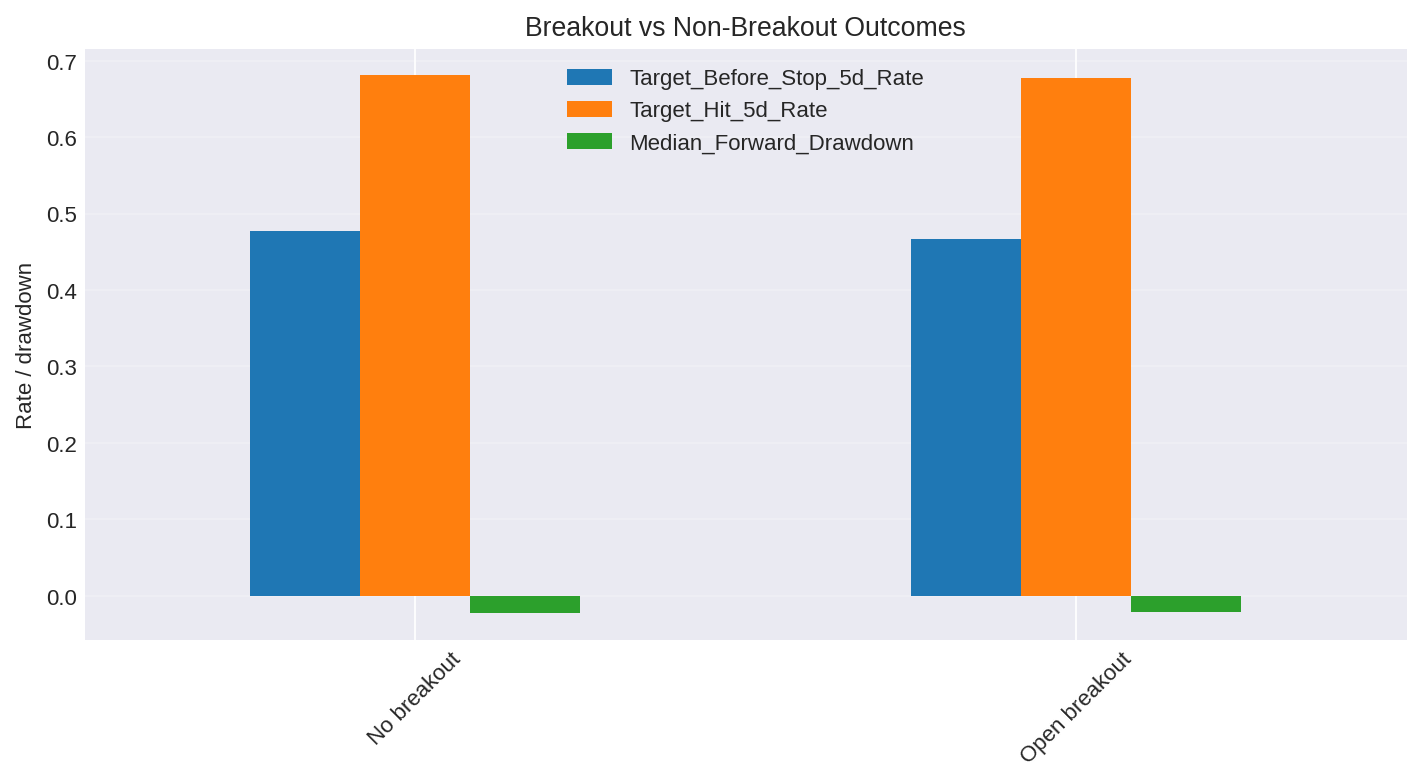

In [14]:
breakout_by_flag, breakout_by_sector = breakout_summary(analysis_table)
breakout_by_flag.to_csv(OUTPUT_DIR / "breakout_summary_by_flag.csv")
breakout_by_sector.to_csv(OUTPUT_DIR / "breakout_summary_by_sector.csv")

breakout_flag_chart_path = save_grouped_bar_chart(
    breakout_by_flag.rename(index={False: "No breakout", True: "Open breakout"}),
    OUTPUT_DIR / "breakout_outcomes_by_flag_chart.png",
    title="Breakout vs Non-Breakout Outcomes",
    columns=["Target_Before_Stop_5d_Rate", "Target_Hit_5d_Rate", "Median_Forward_Drawdown"],
    ylabel="Rate / drawdown",
    figsize=(9, 5),
)

print("Breakout vs non-breakout outcomes")
display(breakout_by_flag)
print("Breakout frequency by sector")
display(breakout_by_sector)
print(f"Saved: {breakout_flag_chart_path}")
display(Image(filename=str(breakout_flag_chart_path)))


### 4.2 Pattern Visualizations


<!-- beginner-explanation -->
**How to read the breakout example charts**

- These charts show individual tickers with price, recent high/low levels, and breakout markers.
- The prior 20-day high is a recent resistance-style level.
- Price opening above that level is marked as a breakout.
- The prior 20-day low is a recent weakness level.
- Use these examples as visual checks so the rule is easy to inspect outside the tables.


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/simple_breakout_examples.png


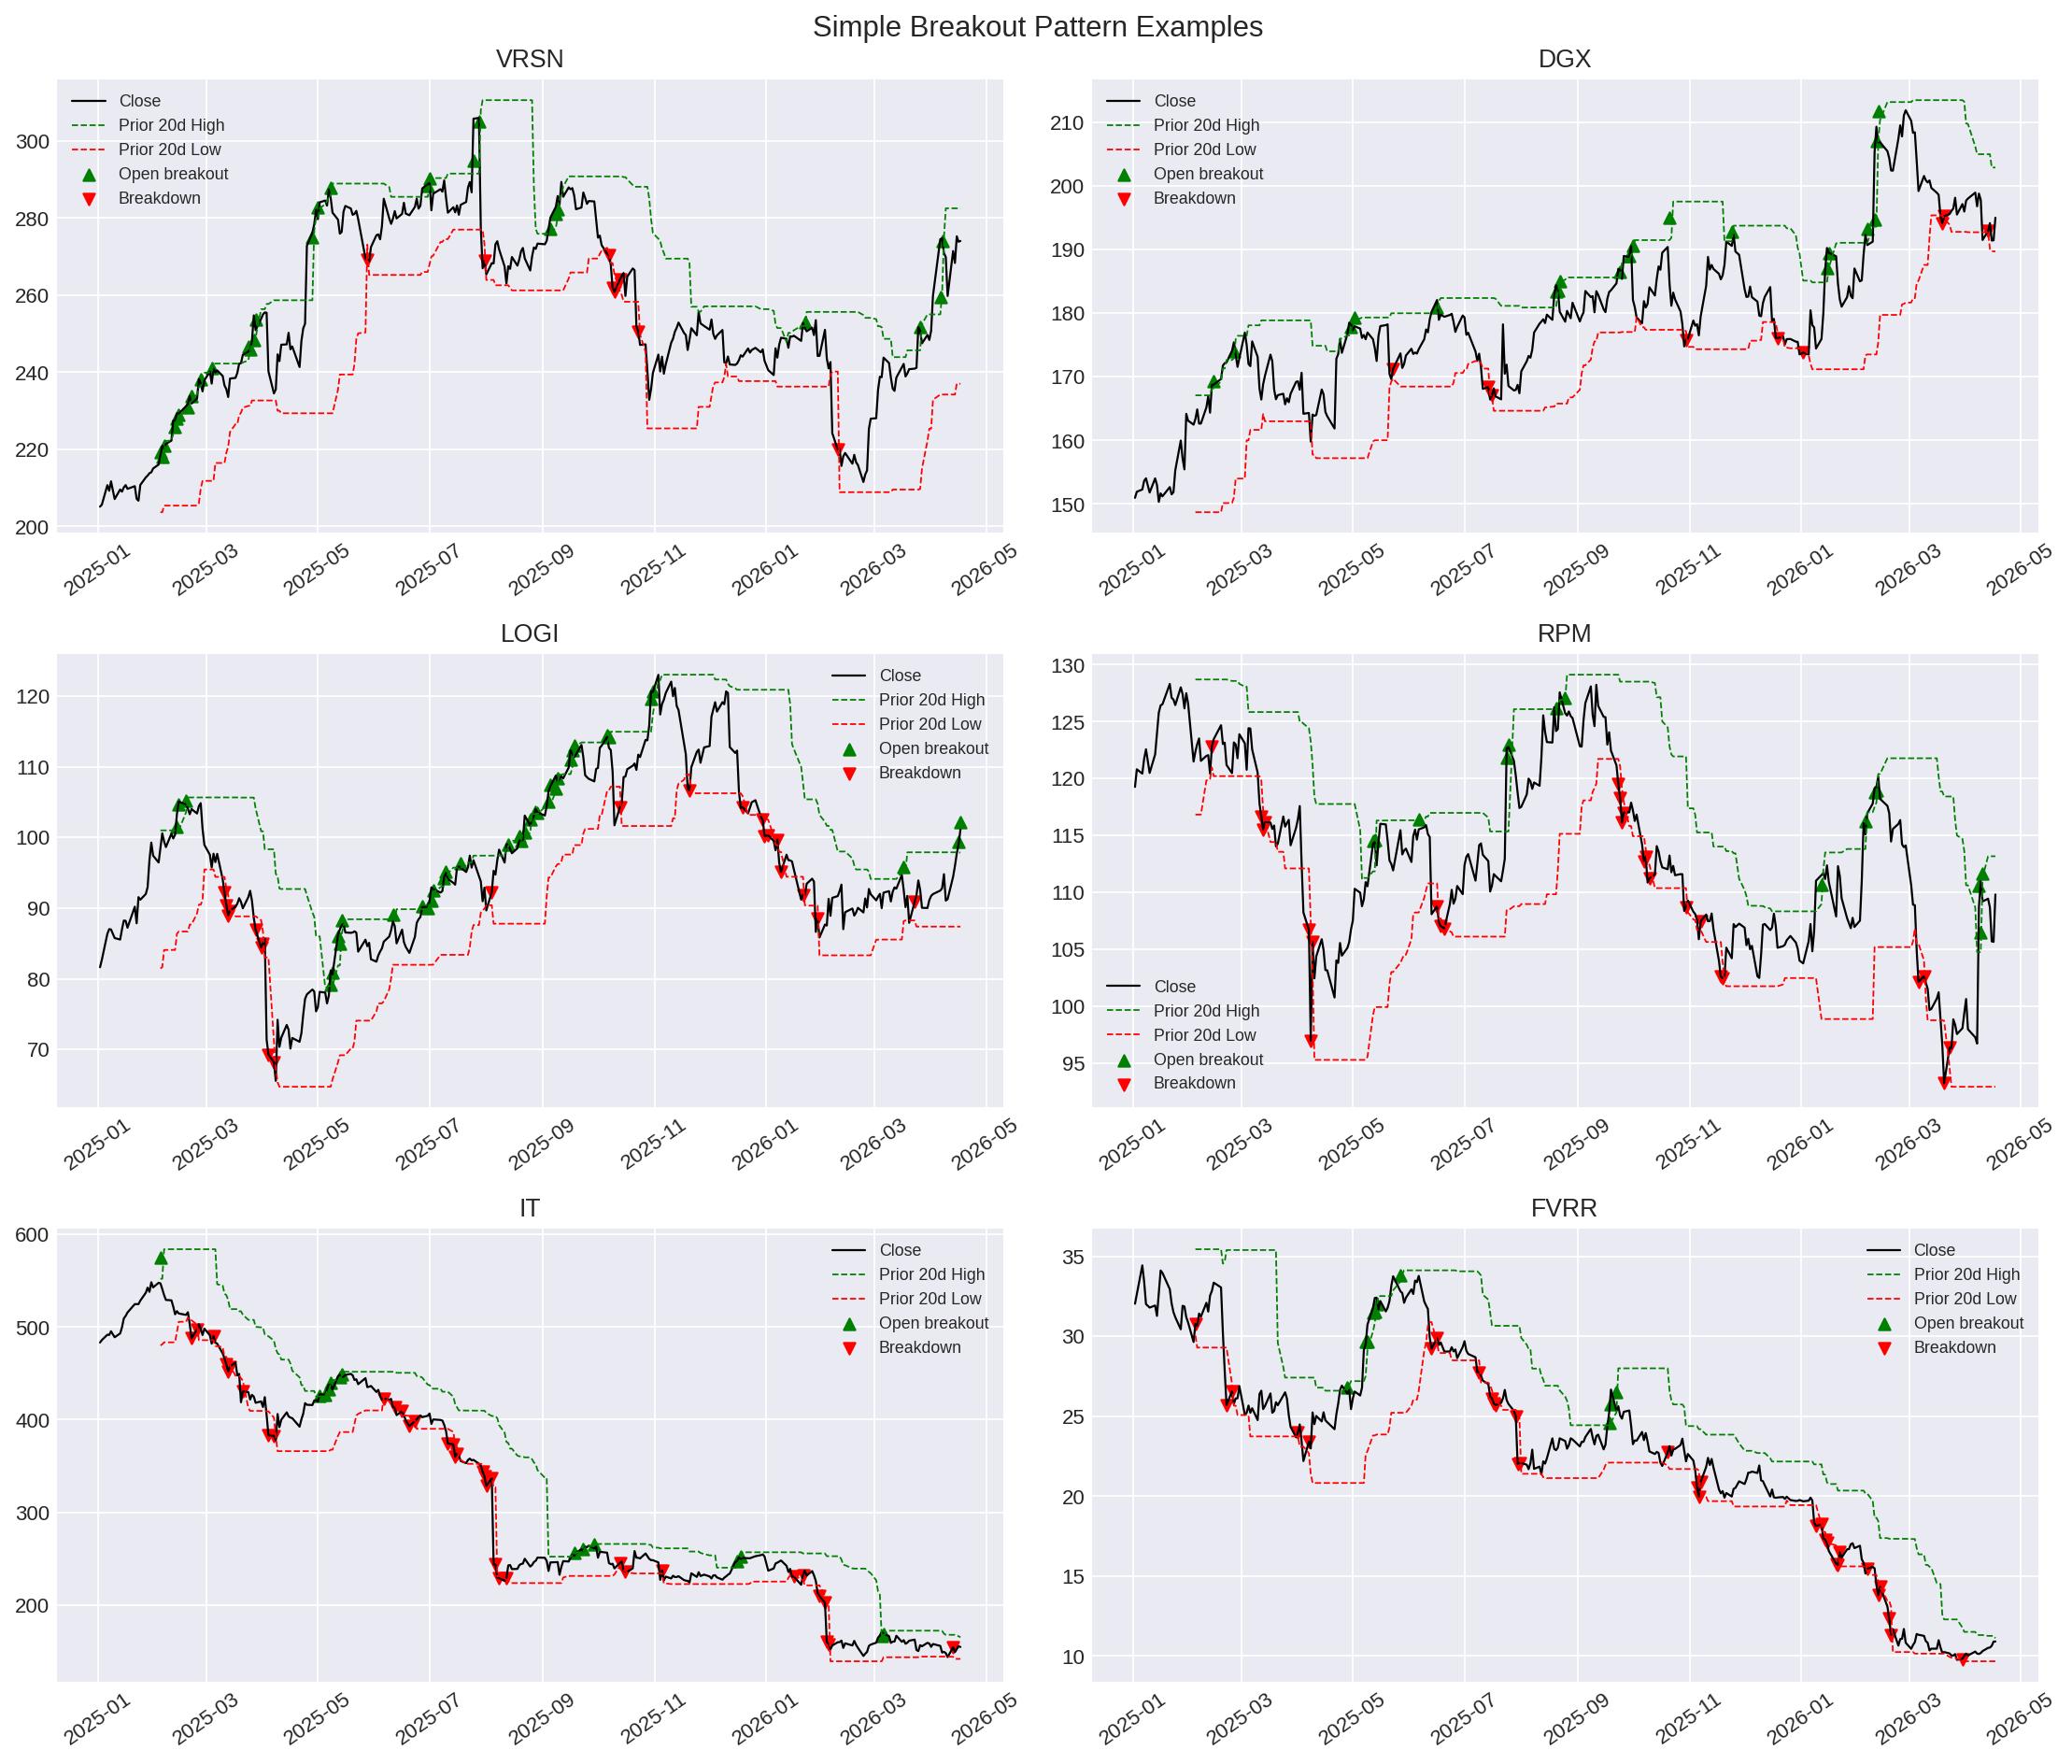

In [15]:
breakout_path = save_breakout_examples(
    analysis_table=analysis_table,
    output_path=OUTPUT_DIR / "simple_breakout_examples.png",
    symbols=showcase_symbols,
)
print(f"Saved: {breakout_path}")
display(Image(filename=str(breakout_path)))


## 5. Target And Label Analysis

### 5.1 Label Creation


<!-- beginner-explanation -->
**How to read target and label creation**

- A **label** is the answer calculated for each historical entry: did the setup succeed or not?
- **Max Forward Return 5d** is the best upside reached during the next five sessions.
- **Min Forward Drawdown 5d** is the worst downside reached during the next five sessions.
- **Close Return 5d** is the return at the end of the fifth session.
- **Days To Target** tells how quickly the target was reached; **0** means the target was reached on the entry day.
- Rows without a full forward window are skipped because they cannot be judged fairly.
- Rows without a full backward window are weak for feature analysis because some indicators would be missing.


Outcome columns: ['target_hit_5d', 'target_before_stop_5d', 'max_forward_return_5d', 'min_forward_drawdown_5d', 'close_return_5d', 'days_to_target']
Rows without full forward window: 240
Rows without full backward window: 3,000
Rows valid for both feature and label analysis: 16,140


,Ticker,Date,Open,target_hit_5d,target_before_stop_5d,max_forward_return_5d,min_forward_drawdown_5d,close_return_5d,days_to_target,valid_forward_window,valid_backward_window,valid_analysis_window
0,AGCO,2025-01-02,94.169998,0.0,0.0,0.007433,-0.052671,-0.041839,NaN,True,False,False
1,AGCO,2025-01-03,91.580002,1.0,1.0,0.028281,-0.036908,-0.007971,1.0,True,False,False
2,AGCO,2025-01-06,93.449997,1.0,0.0,0.046442,-0.056180,0.038951,NaN,True,False,False
3,AGCO,2025-01-07,91.330002,1.0,0.0,0.073908,-0.034271,0.065477,NaN,True,False,False
4,AGCO,2025-01-08,90.550003,1.0,0.0,0.097846,-0.025953,0.075207,NaN,True,False,False
5,AGCO,2025-01-10,89.139999,1.0,1.0,0.125196,-0.010545,0.121831,0.0,True,False,False
6,AGCO,2025-01-13,90.500000,1.0,1.0,0.127514,-0.003867,0.123646,0.0,True,False,False
7,AGCO,2025-01-14,97.209999,1.0,0.0,0.073449,-0.015945,0.060899,NaN,True,False,False
8,AGCO,2025-01-15,98.839996,1.0,0.0,0.055747,-0.016592,0.045225,NaN,True,False,False
9,AGCO,2025-01-16,97.730003,1.0,1.0,0.083393,-0.003786,0.075514,0.0,True,False,False


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/forward_outcome_distributions.png


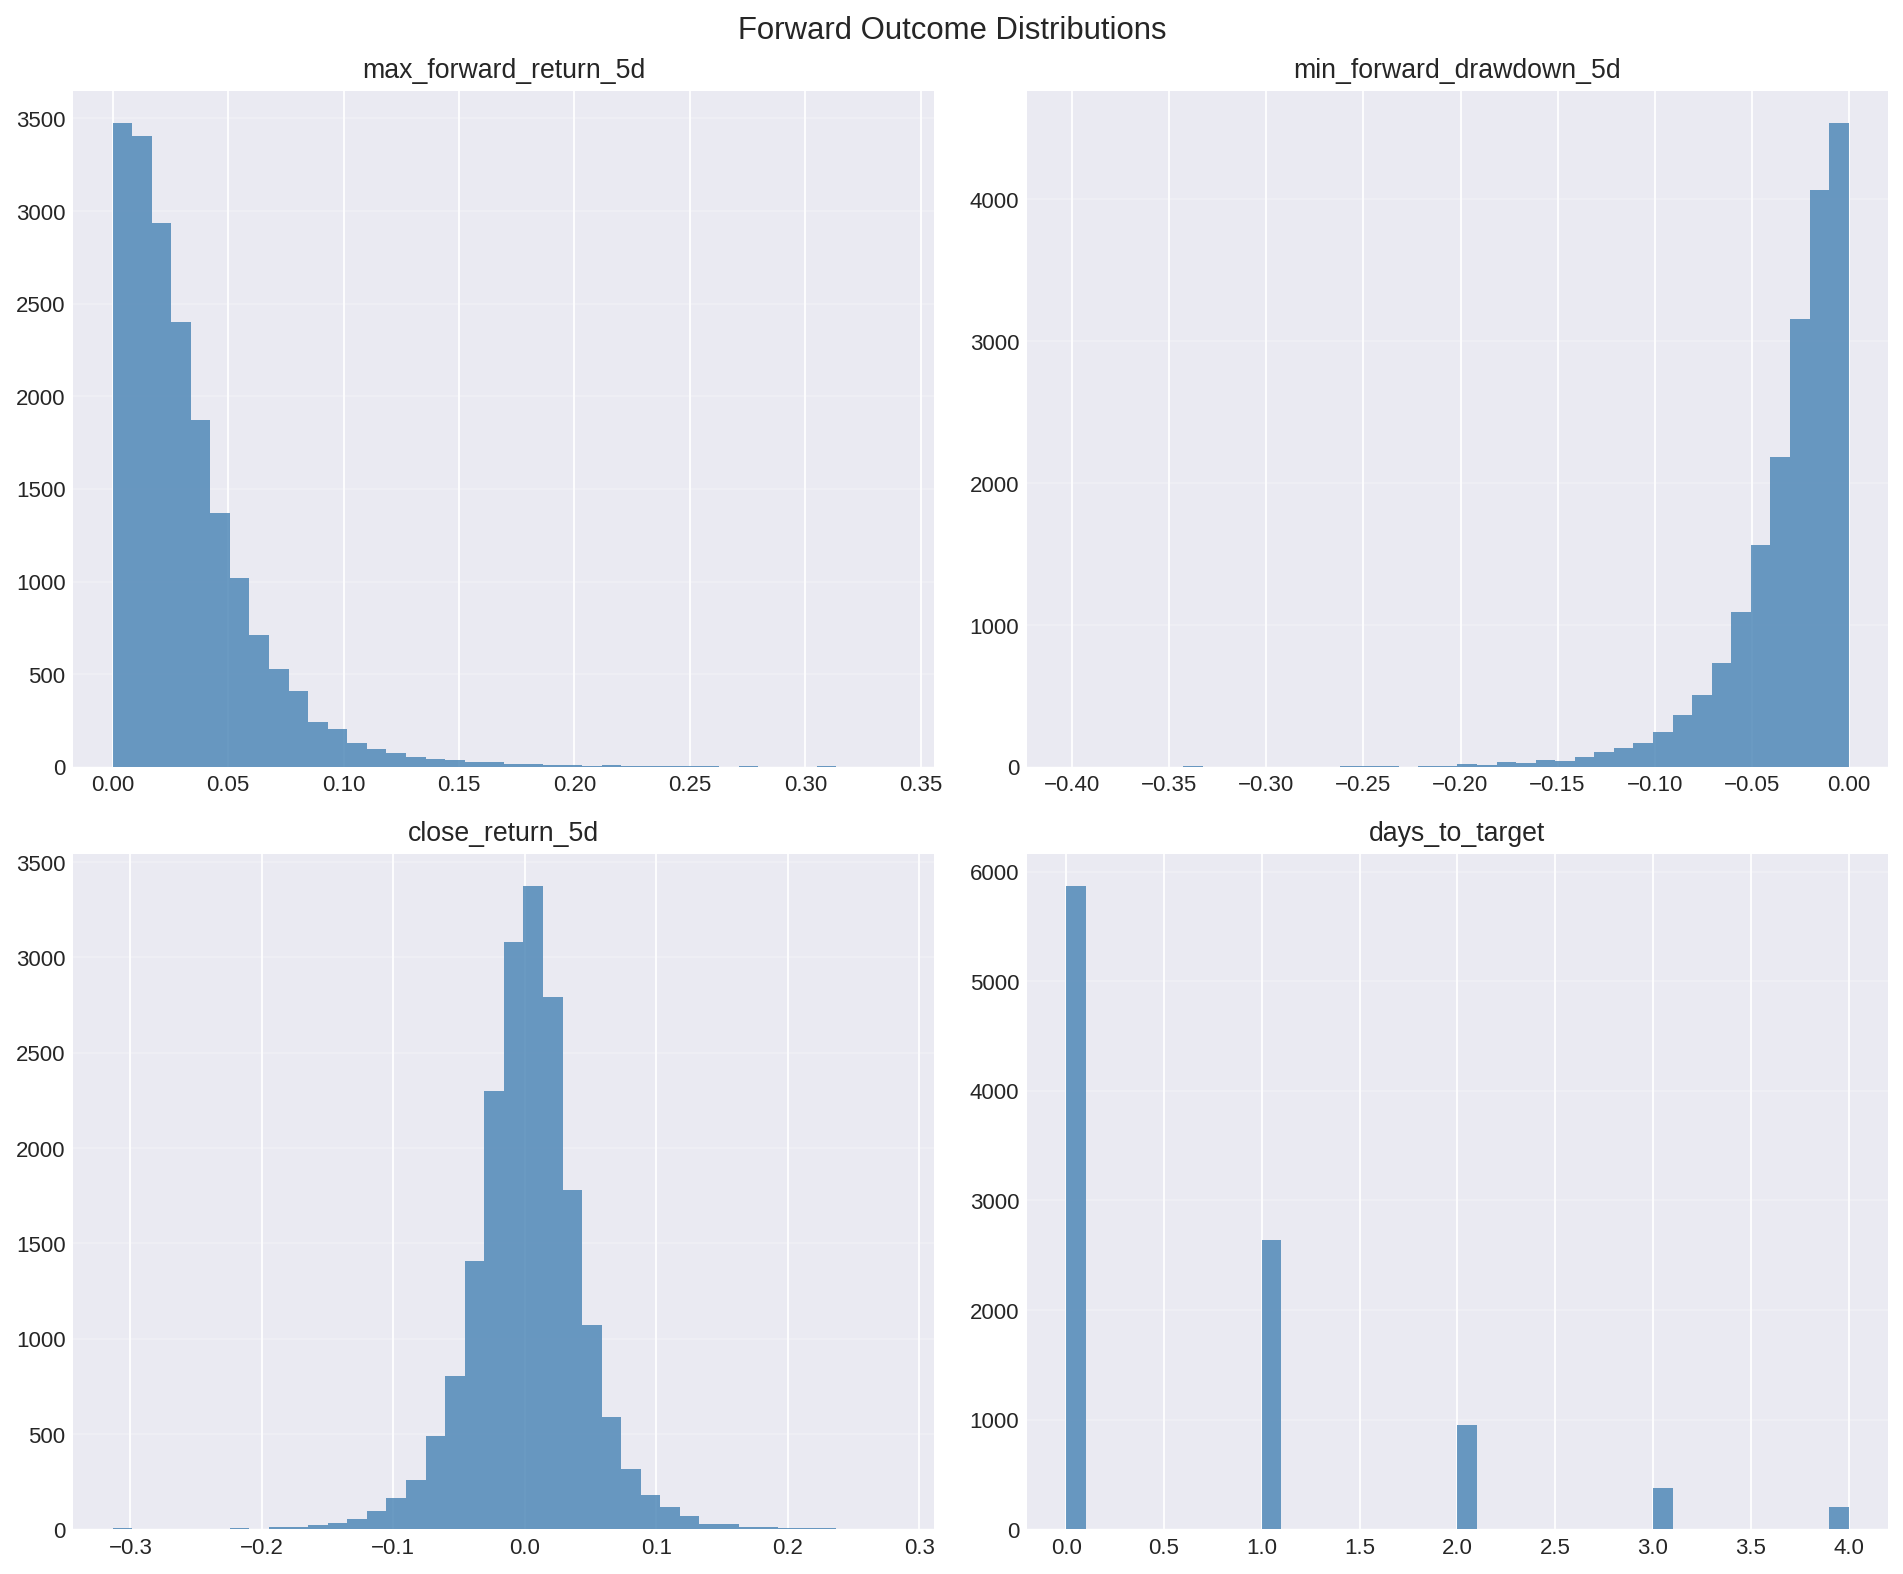

In [16]:
label_cols = [
    "Ticker", "Date", "Open", *OUTCOME_COLUMNS,
    "valid_forward_window", "valid_backward_window", "valid_analysis_window",
]
forward_outcome_hist_path = save_histogram_grid(
    valid_rows,
    OUTPUT_DIR / "forward_outcome_distributions.png",
    columns=["max_forward_return_5d", "min_forward_drawdown_5d", "close_return_5d", "days_to_target"],
    title="Forward Outcome Distributions",
    bins=40,
    figsize=(12, 10),
)

print("Outcome columns:", OUTCOME_COLUMNS)
print(f"Rows without full forward window: {(~analysis_table['valid_forward_window']).sum():,}")
print(f"Rows without full backward window: {(~analysis_table['valid_backward_window']).sum():,}")
print(f"Rows valid for both feature and label analysis: {analysis_table['valid_analysis_window'].sum():,}")
display(analysis_table[label_cols].dropna(subset=["target_before_stop_5d"]).head(10))
print(f"Saved: {forward_outcome_hist_path}")
display(Image(filename=str(forward_outcome_hist_path)))


### 5.2 Label Prevalence


<!-- beginner-explanation -->
**How to read label prevalence**

- **Prevalence** means how often something happened.
- Overall prevalence shows how common target hits and target-before-stop successes were across the whole dataset.
- By-sector prevalence shows whether some sectors had better historical behavior.
- The volatility-bucket table groups entries by recent volatility.
- The volatility-bucket chart uses two line panels because success rate and drawdown magnitude live on different scales.
- If a higher-volatility bucket has a better target-hit rate but worse drawdown, it offered more upside but also more uncomfortable downside.


Overall label prevalence


,Metric,Overall_Rate
0,target_hit_5d,0.680512
1,target_before_stop_5d,0.476594


By sector


,Samples,Target_Hit_5d_Rate,Target_Before_Stop_5d_Rate,Median_Forward_Drawdown
Sector,,,,
Healthcare,1276,0.719436,0.507053,-0.022514
Financial,4785,0.677952,0.482759,-0.023217
Industrial,6061,0.686685,0.481109,-0.021550
Technology,3190,0.659561,0.473981,-0.022722
Real Estate,1914,0.623302,0.460293,-0.019990
Consumer,1914,0.733542,0.447231,-0.031792


By volatility bucket


,Samples,Target_Before_Stop_5d_Rate,Median_Forward_Drawdown
Volatility_Bucket,,,
"(0.00321, 0.0131]",4470,0.456152,-0.018681
"(0.0131, 0.017]",4470,0.479866,-0.022234
"(0.017, 0.0226]",4470,0.489038,-0.024662
"(0.0226, 0.0763]",4470,0.469575,-0.028455


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/label_prevalence_by_volatility_bucket_chart.png


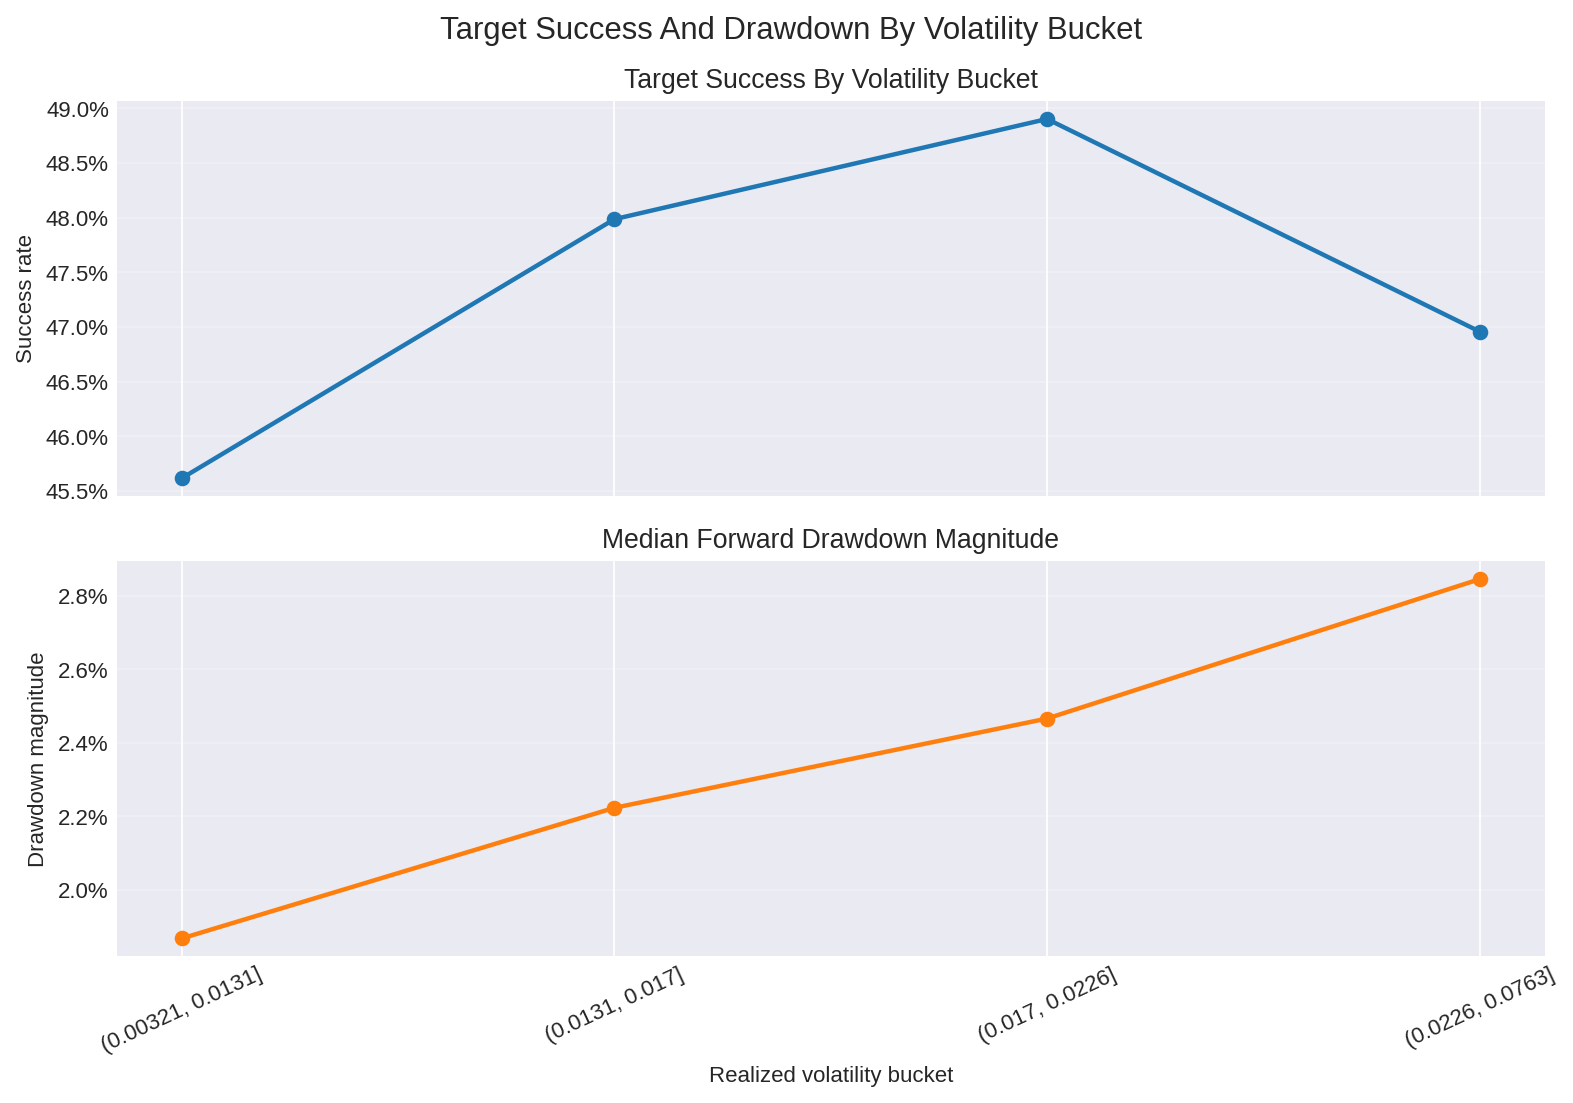

In [17]:
label_prevalence = pd.DataFrame({
    "Metric": ["target_hit_5d", "target_before_stop_5d"],
    "Overall_Rate": [valid_rows["target_hit_5d"].mean(), valid_rows["target_before_stop_5d"].mean()],
})

by_ticker = valid_rows.groupby("Ticker").agg(
    Samples=("target_before_stop_5d", "count"),
    Target_Hit_5d_Rate=("target_hit_5d", "mean"),
    Target_Before_Stop_5d_Rate=("target_before_stop_5d", "mean"),
    Median_Forward_Drawdown=("min_forward_drawdown_5d", "median"),
).sort_values("Target_Before_Stop_5d_Rate", ascending=False)

by_sector = valid_rows.groupby("Sector").agg(
    Samples=("target_before_stop_5d", "count"),
    Target_Hit_5d_Rate=("target_hit_5d", "mean"),
    Target_Before_Stop_5d_Rate=("target_before_stop_5d", "mean"),
    Median_Forward_Drawdown=("min_forward_drawdown_5d", "median"),
).sort_values("Target_Before_Stop_5d_Rate", ascending=False)

vol_view = valid_rows.dropna(subset=["realized_vol_20"]).copy()
vol_view["Volatility_Bucket"] = pd.qcut(vol_view["realized_vol_20"], q=4, duplicates="drop")
by_vol_bucket = vol_view.groupby("Volatility_Bucket", observed=False).agg(
    Samples=("target_before_stop_5d", "count"),
    Target_Before_Stop_5d_Rate=("target_before_stop_5d", "mean"),
    Median_Forward_Drawdown=("min_forward_drawdown_5d", "median"),
)

label_prevalence.to_csv(OUTPUT_DIR / "overall_label_prevalence.csv", index=False)
by_ticker.to_csv(OUTPUT_DIR / "label_prevalence_by_ticker.csv")
by_sector.to_csv(OUTPUT_DIR / "label_prevalence_by_sector.csv")
by_vol_bucket.to_csv(OUTPUT_DIR / "label_prevalence_by_volatility_bucket.csv")

volatility_plot = by_vol_bucket.copy()
volatility_plot.index = volatility_plot.index.astype(str)
volatility_plot["Median_Forward_Drawdown_Magnitude"] = volatility_plot["Median_Forward_Drawdown"].abs()

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(
    volatility_plot.index,
    volatility_plot["Target_Before_Stop_5d_Rate"],
    marker="o",
    linewidth=2,
    color="tab:blue",
)
axes[0].set_title("Target Success By Volatility Bucket")
axes[0].set_ylabel("Success rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(
    volatility_plot.index,
    volatility_plot["Median_Forward_Drawdown_Magnitude"],
    marker="o",
    linewidth=2,
    color="tab:orange",
)
axes[1].set_title("Median Forward Drawdown Magnitude")
axes[1].set_xlabel("Realized volatility bucket")
axes[1].set_ylabel("Drawdown magnitude")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.25)
fig.suptitle("Target Success And Drawdown By Volatility Bucket", fontsize=14)
fig.tight_layout()
by_vol_bucket_path = OUTPUT_DIR / "label_prevalence_by_volatility_bucket_chart.png"
fig.savefig(by_vol_bucket_path, dpi=160, bbox_inches="tight")
plt.close(fig)

print("Overall label prevalence")
display(label_prevalence)
print("By sector")
display(by_sector)
print("By volatility bucket")
display(by_vol_bucket)
print(f"Saved: {by_vol_bucket_path}")
display(Image(filename=str(by_vol_bucket_path)))


### 5.3 Low-Risk Sector Summary


<!-- beginner-explanation -->
**How to read the low-risk sector summary**

- This table is meant to simplify risk.
- **Target Before Stop 5d Rate** shows how often the target was reached before the stop.
- **Median Forward Drawdown** shows the typical worst dip over five sessions.
- **P10 Forward Drawdown** is a worse-case-style percentile: about 10% of entries had drawdowns worse than this number.
- **P10 Forward Drawdown = -6%** means one out of ten historical entries fell more than about 6% during the five-session window.
- **Samples** tells you how much evidence the sector summary is based on.


In [18]:
low_risk_sector_summary = sector_summary[[
    "Samples", "Tickers", "Target_Before_Stop_5d_Rate", "Median_Forward_Drawdown",
    "P10_Forward_Drawdown", "Positive_Week_Rate", "Weekly_Volatility",
]].sort_values(["Target_Before_Stop_5d_Rate", "Median_Forward_Drawdown"], ascending=[False, False])
low_risk_sector_summary.to_csv(OUTPUT_DIR / "low_risk_sector_summary.csv")
display(low_risk_sector_summary)


,Samples,Tickers,Target_Before_Stop_5d_Rate,Median_Forward_Drawdown,P10_Forward_Drawdown,Positive_Week_Rate,Weekly_Volatility
Sector,,,,,,,
Healthcare,1276,4,0.507053,-0.022514,-0.065939,0.563433,0.042603
Financial,4785,15,0.482759,-0.023217,-0.068757,0.545274,0.041138
Industrial,6061,19,0.481109,-0.021550,-0.064735,0.553024,0.040521
Technology,3190,10,0.473981,-0.022722,-0.073407,0.525373,0.046257
Real Estate,1914,6,0.460293,-0.019990,-0.059929,0.519900,0.034253
Consumer,1914,6,0.447231,-0.031792,-0.084737,0.500000,0.048964


## 6. Feature Engineering And Correlation Analysis

### 6.1 Analysis Feature Table


<!-- beginner-explanation -->
**How to read the analysis feature table**

- A **feature** is an input measurement that might help explain or later predict an outcome.
- Section 6.1 now summarizes features per ticker instead of showing one row per ticker per day.
- **Valid Analysis Rows** tells how many ticker/date rows had both usable features and usable future labels.
- Feature columns such as **ret_5d**, **rsi_14**, and **realized_vol_20** are averaged per ticker across valid analysis rows.
- Outcome columns such as **Target Before Stop 5d Rate** summarize how often the future label succeeded for each ticker.
- The raw day-level analysis table is still saved to CSV for later modeling work.


In [19]:
analysis_table.to_csv(OUTPUT_DIR / "analysis_feature_table.csv", index=False)
print(f"Analysis table shape: {analysis_table.shape}")
print(f"Feature count: {len(FEATURE_COLUMNS)}")
print(f"Outcome count: {len(OUTCOME_COLUMNS)}")
print(f"Valid backward rows: {analysis_table['valid_backward_window'].sum():,}")
print(f"Valid forward rows: {analysis_table['valid_forward_window'].sum():,}")
print(f"Valid analysis rows: {analysis_table['valid_analysis_window'].sum():,}")

feature_snapshot_columns = [
    "ret_5d", "ret_20d", "rsi_14", "macd_hist", "bb_width_20",
    "realized_vol_20", "atr14_norm", "open_above_prior_20d_high",
]

ticker_feature_table = valid_analysis_rows.groupby(["Ticker", "Sector"]).agg(
    Valid_Analysis_Rows=("target_before_stop_5d", "count"),
    Target_Before_Stop_5d_Rate=("target_before_stop_5d", "mean"),
    Target_Hit_5d_Rate=("target_hit_5d", "mean"),
    Median_Max_Forward_Return_5d=("max_forward_return_5d", "median"),
    Median_Min_Forward_Drawdown_5d=("min_forward_drawdown_5d", "median"),
    **{f"Mean_{col}": (col, "mean") for col in feature_snapshot_columns},
).reset_index().sort_values("Target_Before_Stop_5d_Rate", ascending=False)

ticker_feature_table.to_csv(OUTPUT_DIR / "ticker_feature_summary.csv", index=False)
print("Ticker-level feature summary")
display(ticker_feature_table.head(20))


Analysis table shape: (19380, 48)
Feature count: 25
Outcome count: 6
Valid backward rows: 16,380
Valid forward rows: 19,140
Valid analysis rows: 16,140
Ticker-level feature summary


,Ticker,Sector,Valid_Analysis_Rows,Target_Before_Stop_5d_Rate,Target_Hit_5d_Rate,Median_Max_Forward_Return_5d,Median_Min_Forward_Drawdown_5d,Mean_ret_5d,Mean_ret_20d,Mean_rsi_14,Mean_macd_hist,Mean_bb_width_20,Mean_realized_vol_20,Mean_atr14_norm,Mean_open_above_prior_20d_high
34,MTB,Financial,269,0.550186,0.684015,0.022912,-0.016850,0.004889,0.010694,53.113706,0.057661,0.116127,0.015572,0.023524,0.100372
27,LOGI,Technology,269,0.546468,0.684015,0.027034,-0.019477,0.001656,0.000255,51.348913,0.000431,0.155563,0.022159,0.025711,0.118959
24,KLAC,Technology,269,0.539033,0.862454,0.042526,-0.026961,0.018372,0.062086,57.621663,0.509324,0.181516,0.029114,0.037203,0.141264
43,ROK,Industrial,269,0.535316,0.732342,0.028753,-0.018000,0.008019,0.024330,55.526929,-0.013595,0.128388,0.018545,0.027256,0.137546
53,UBSI,Financial,269,0.535316,0.657993,0.024561,-0.016763,0.004870,0.012523,52.620516,0.014077,0.100941,0.015833,0.023132,0.070632
50,SSB,Financial,269,0.531599,0.706320,0.026426,-0.022654,0.001800,-0.000644,50.816780,0.020326,0.113627,0.017323,0.026568,0.085502
32,MLI,Industrial,269,0.527881,0.747212,0.029063,-0.017569,0.007953,0.027967,56.980806,-0.015194,0.120285,0.017725,0.025800,0.178439
5,BURL,Consumer,269,0.520446,0.802974,0.042621,-0.028954,0.007939,0.025181,53.254291,0.219341,0.149476,0.025632,0.036610,0.092937
25,KMT,Industrial,269,0.516729,0.784387,0.037090,-0.023631,0.012283,0.045149,56.728211,0.001138,0.172603,0.024390,0.032161,0.130112
19,HXL,Industrial,269,0.516729,0.747212,0.032721,-0.023887,0.008077,0.024537,55.102906,0.007212,0.135975,0.020059,0.029347,0.100372


### 6.2 Feature Set Summary


<!-- beginner-explanation -->
**How to read the feature summary**

- This table describes each feature statistically.
- **Count** is how many non-missing values exist.
- **Mean** is the average.
- **Std** is standard deviation, a measure of spread.
- **Min**, **25%**, **50%**, **75%**, and **Max** show the range of values.
- **50%** is the median.
- The selected feature distribution chart shows whether a feature is clustered, skewed, or has outliers.
- **Outliers** are unusually large or small values that may deserve extra caution.


,count,mean,std,min,25%,50%,75%,max
ret_5d,19020.0,0.001914,0.043959,-0.328859,-0.021370,0.002588,0.025796,0.291788
ret_20d,18120.0,0.004101,0.087305,-0.407680,-0.049812,0.003657,0.055517,0.425457
close_above_sma_20,18180.0,0.523212,0.499475,0.000000,0.000000,1.000000,1.000000,1.000000
close_above_sma_50,16380.0,0.520147,0.499609,0.000000,0.000000,1.000000,1.000000,1.000000
dist_prev_close_sma_20,18180.0,0.000878,0.048696,-0.318045,-0.025757,0.002228,0.029155,0.250954
dist_open_sma_20,18180.0,0.000772,0.050166,-0.363033,-0.026069,0.001904,0.029756,0.242248
dist_open_ema_20,18180.0,0.000303,0.043294,-0.353350,-0.022470,0.001998,0.025617,0.210421
sma_20_slope_5d,17880.0,0.000158,0.020920,-0.111955,-0.012287,0.000866,0.013010,0.087934
rsi_14,18480.0,51.574903,12.424660,9.184319,42.780033,51.337592,60.292769,94.848033
macd_hist,17340.0,-0.007587,1.964801,-35.943215,-0.465480,0.003255,0.446323,32.333375


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/selected_feature_distributions.png


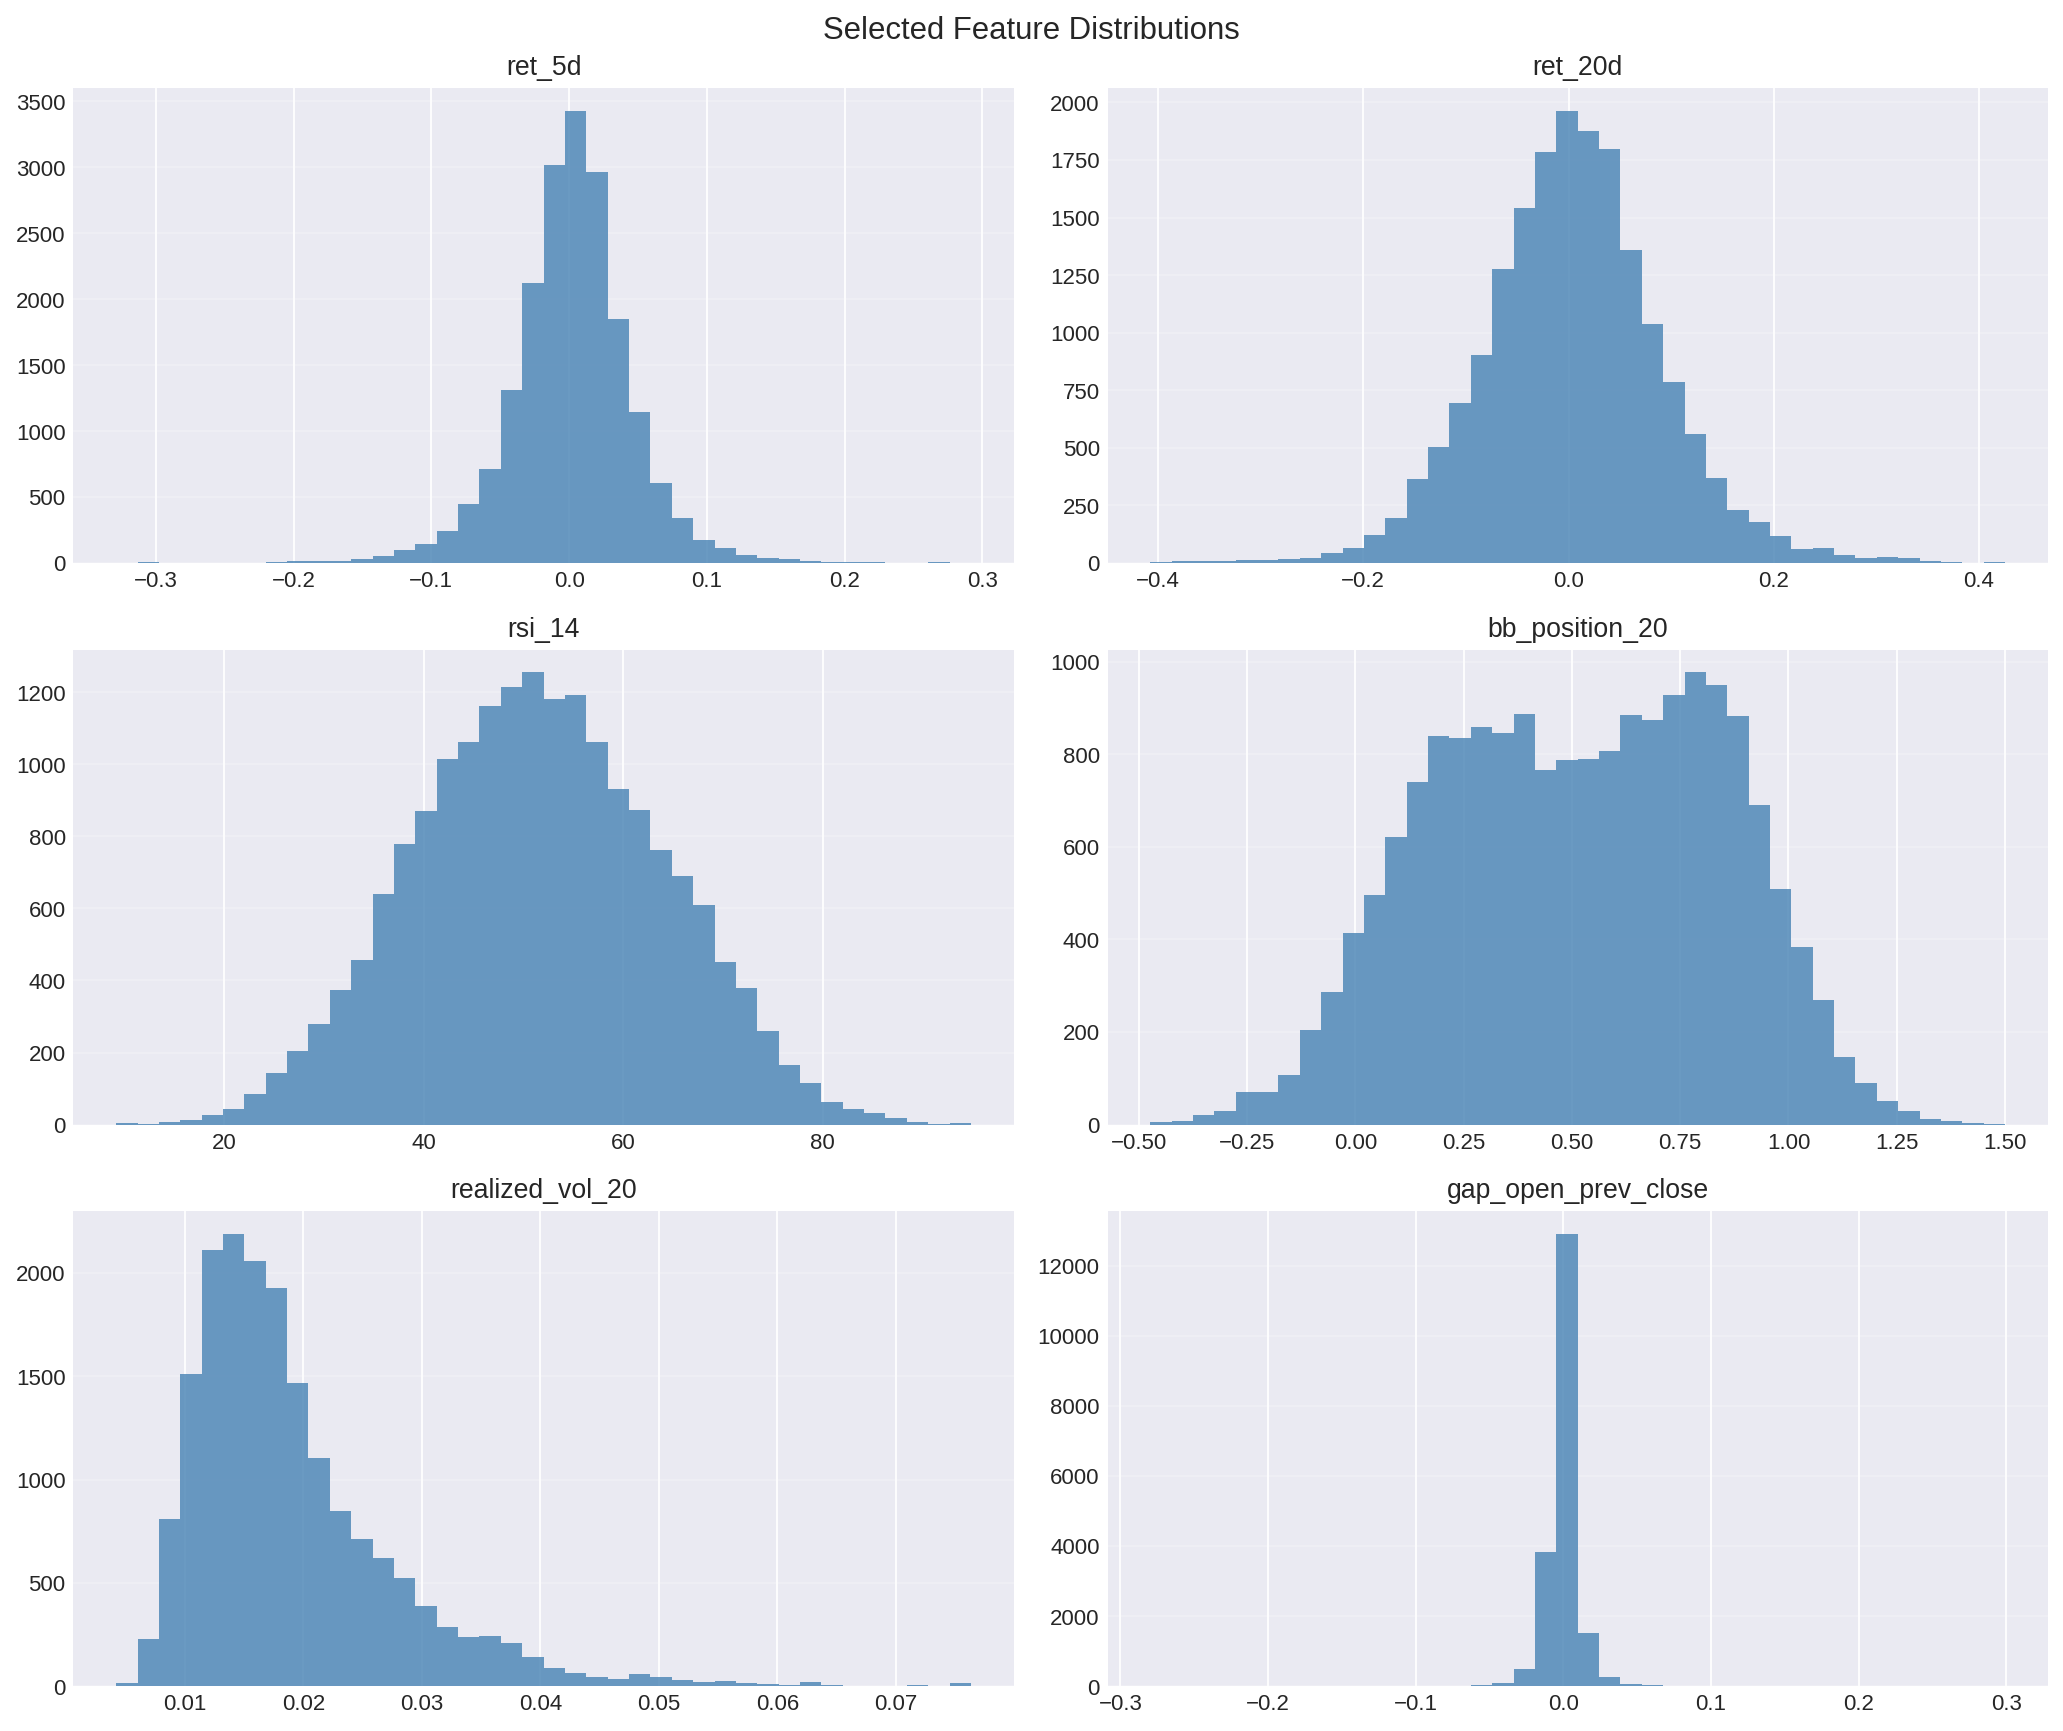

In [20]:
feature_summary = analysis_table[FEATURE_COLUMNS].describe().T
feature_summary.to_csv(OUTPUT_DIR / "feature_summary.csv")

feature_distribution_path = save_histogram_grid(
    analysis_table,
    OUTPUT_DIR / "selected_feature_distributions.png",
    columns=["ret_5d", "ret_20d", "rsi_14", "bb_position_20", "realized_vol_20", "gap_open_prev_close"],
    title="Selected Feature Distributions",
    bins=40,
    figsize=(13, 11),
)

display(feature_summary)
print(f"Saved: {feature_distribution_path}")
display(Image(filename=str(feature_distribution_path)))


### 6.3 Correlation Maps


<!-- beginner-explanation -->
**How to read correlation maps**

- A feature-to-label correlation asks whether a feature tends to be higher or lower when the outcome succeeds.
- Positive correlation means higher feature values tended to go with higher outcome values.
- Negative correlation means higher feature values tended to go with lower outcome values.
- Correlation does not prove causation.
- A small correlation, even if ranked near the top, should not be overstated.
- Feature-to-feature correlation shows redundant features that move almost the same way.


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/feature_label_correlation_heatmap.png


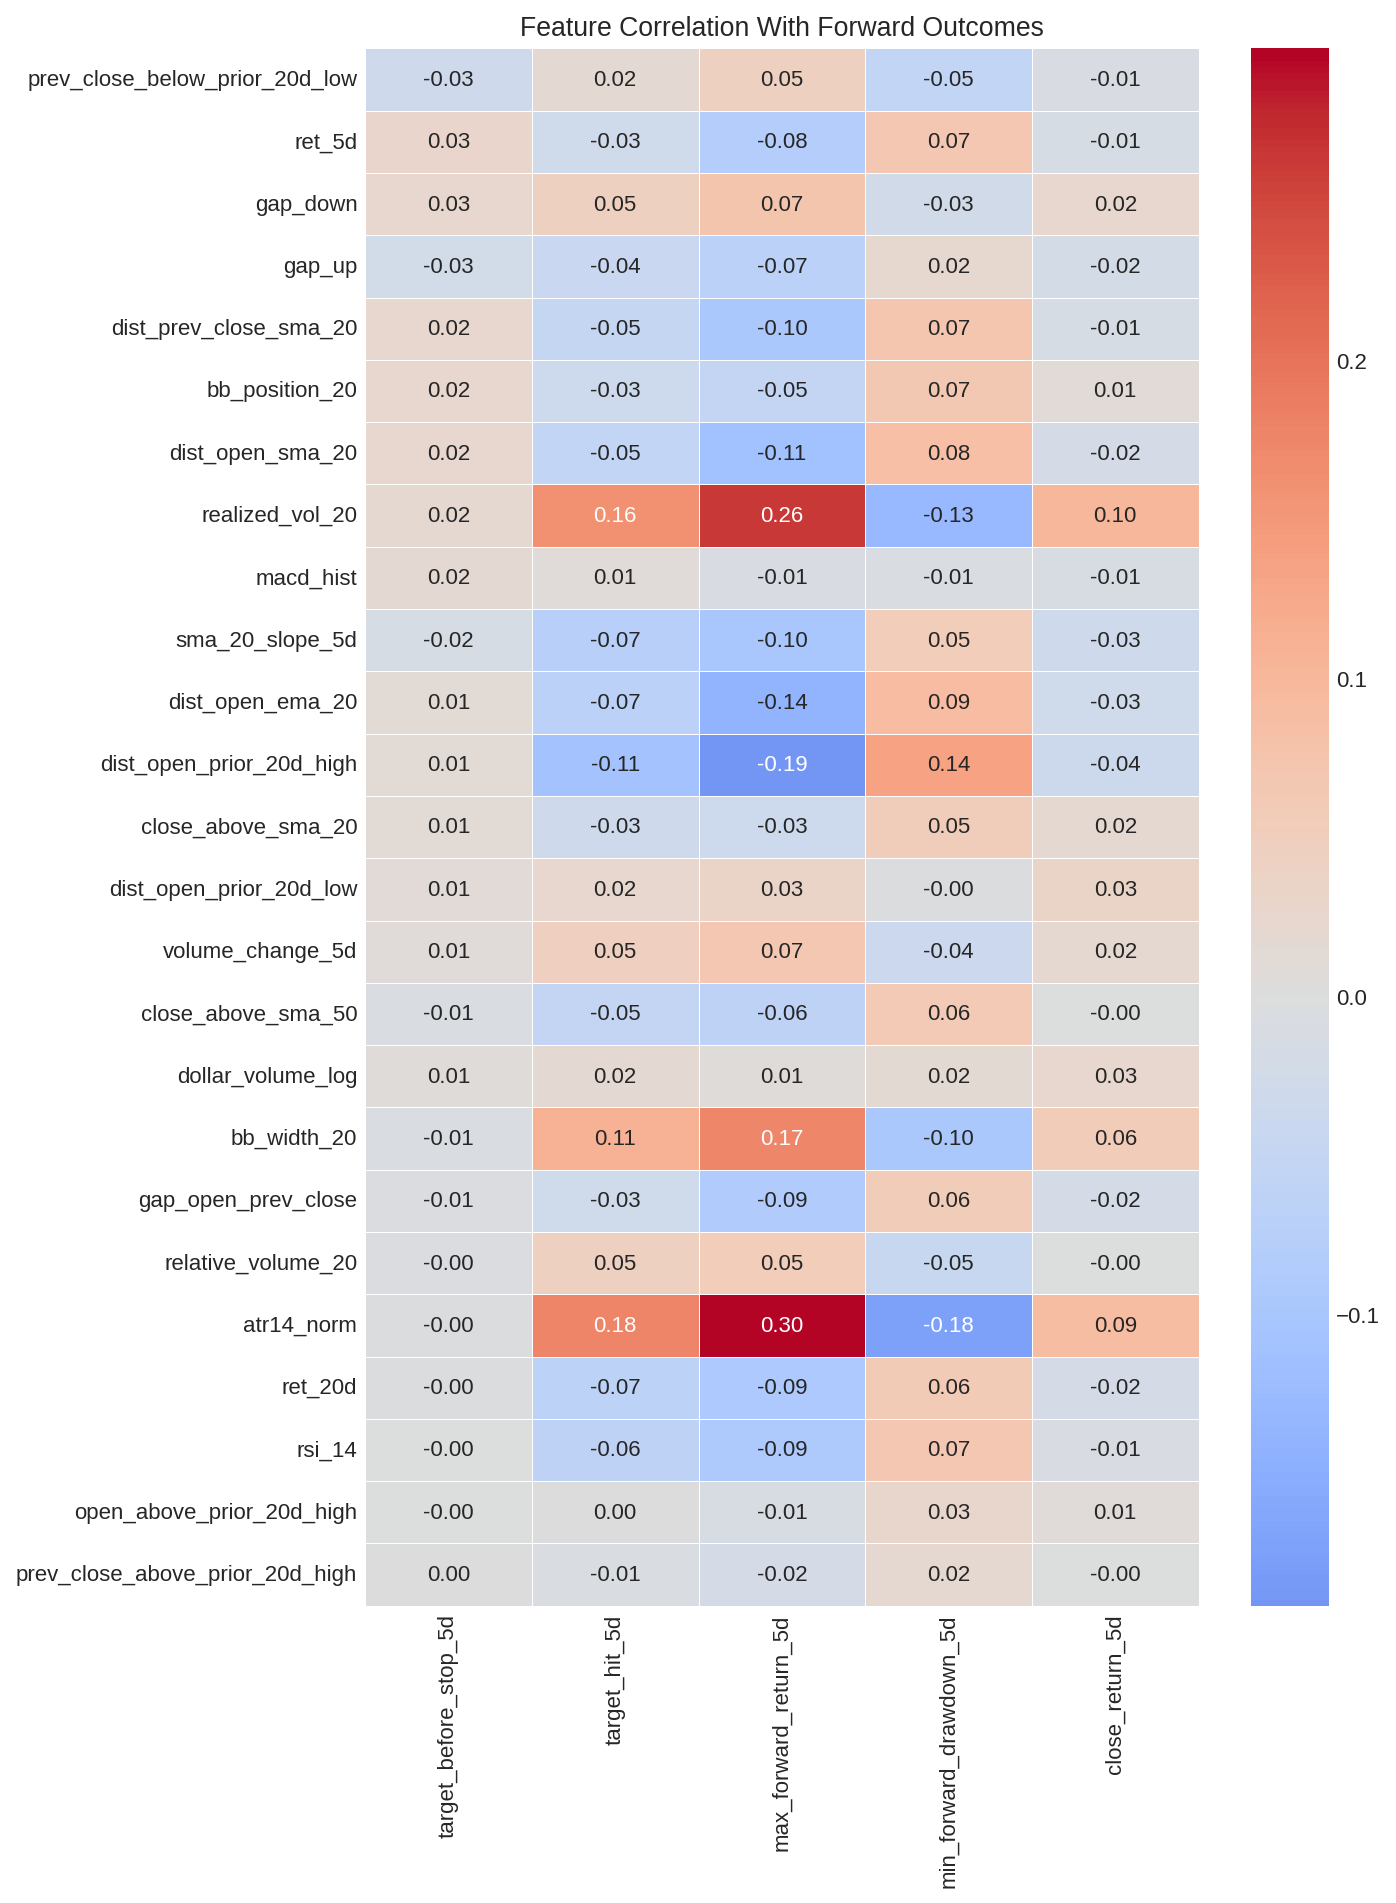

Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/feature_to_feature_correlation_heatmap.png


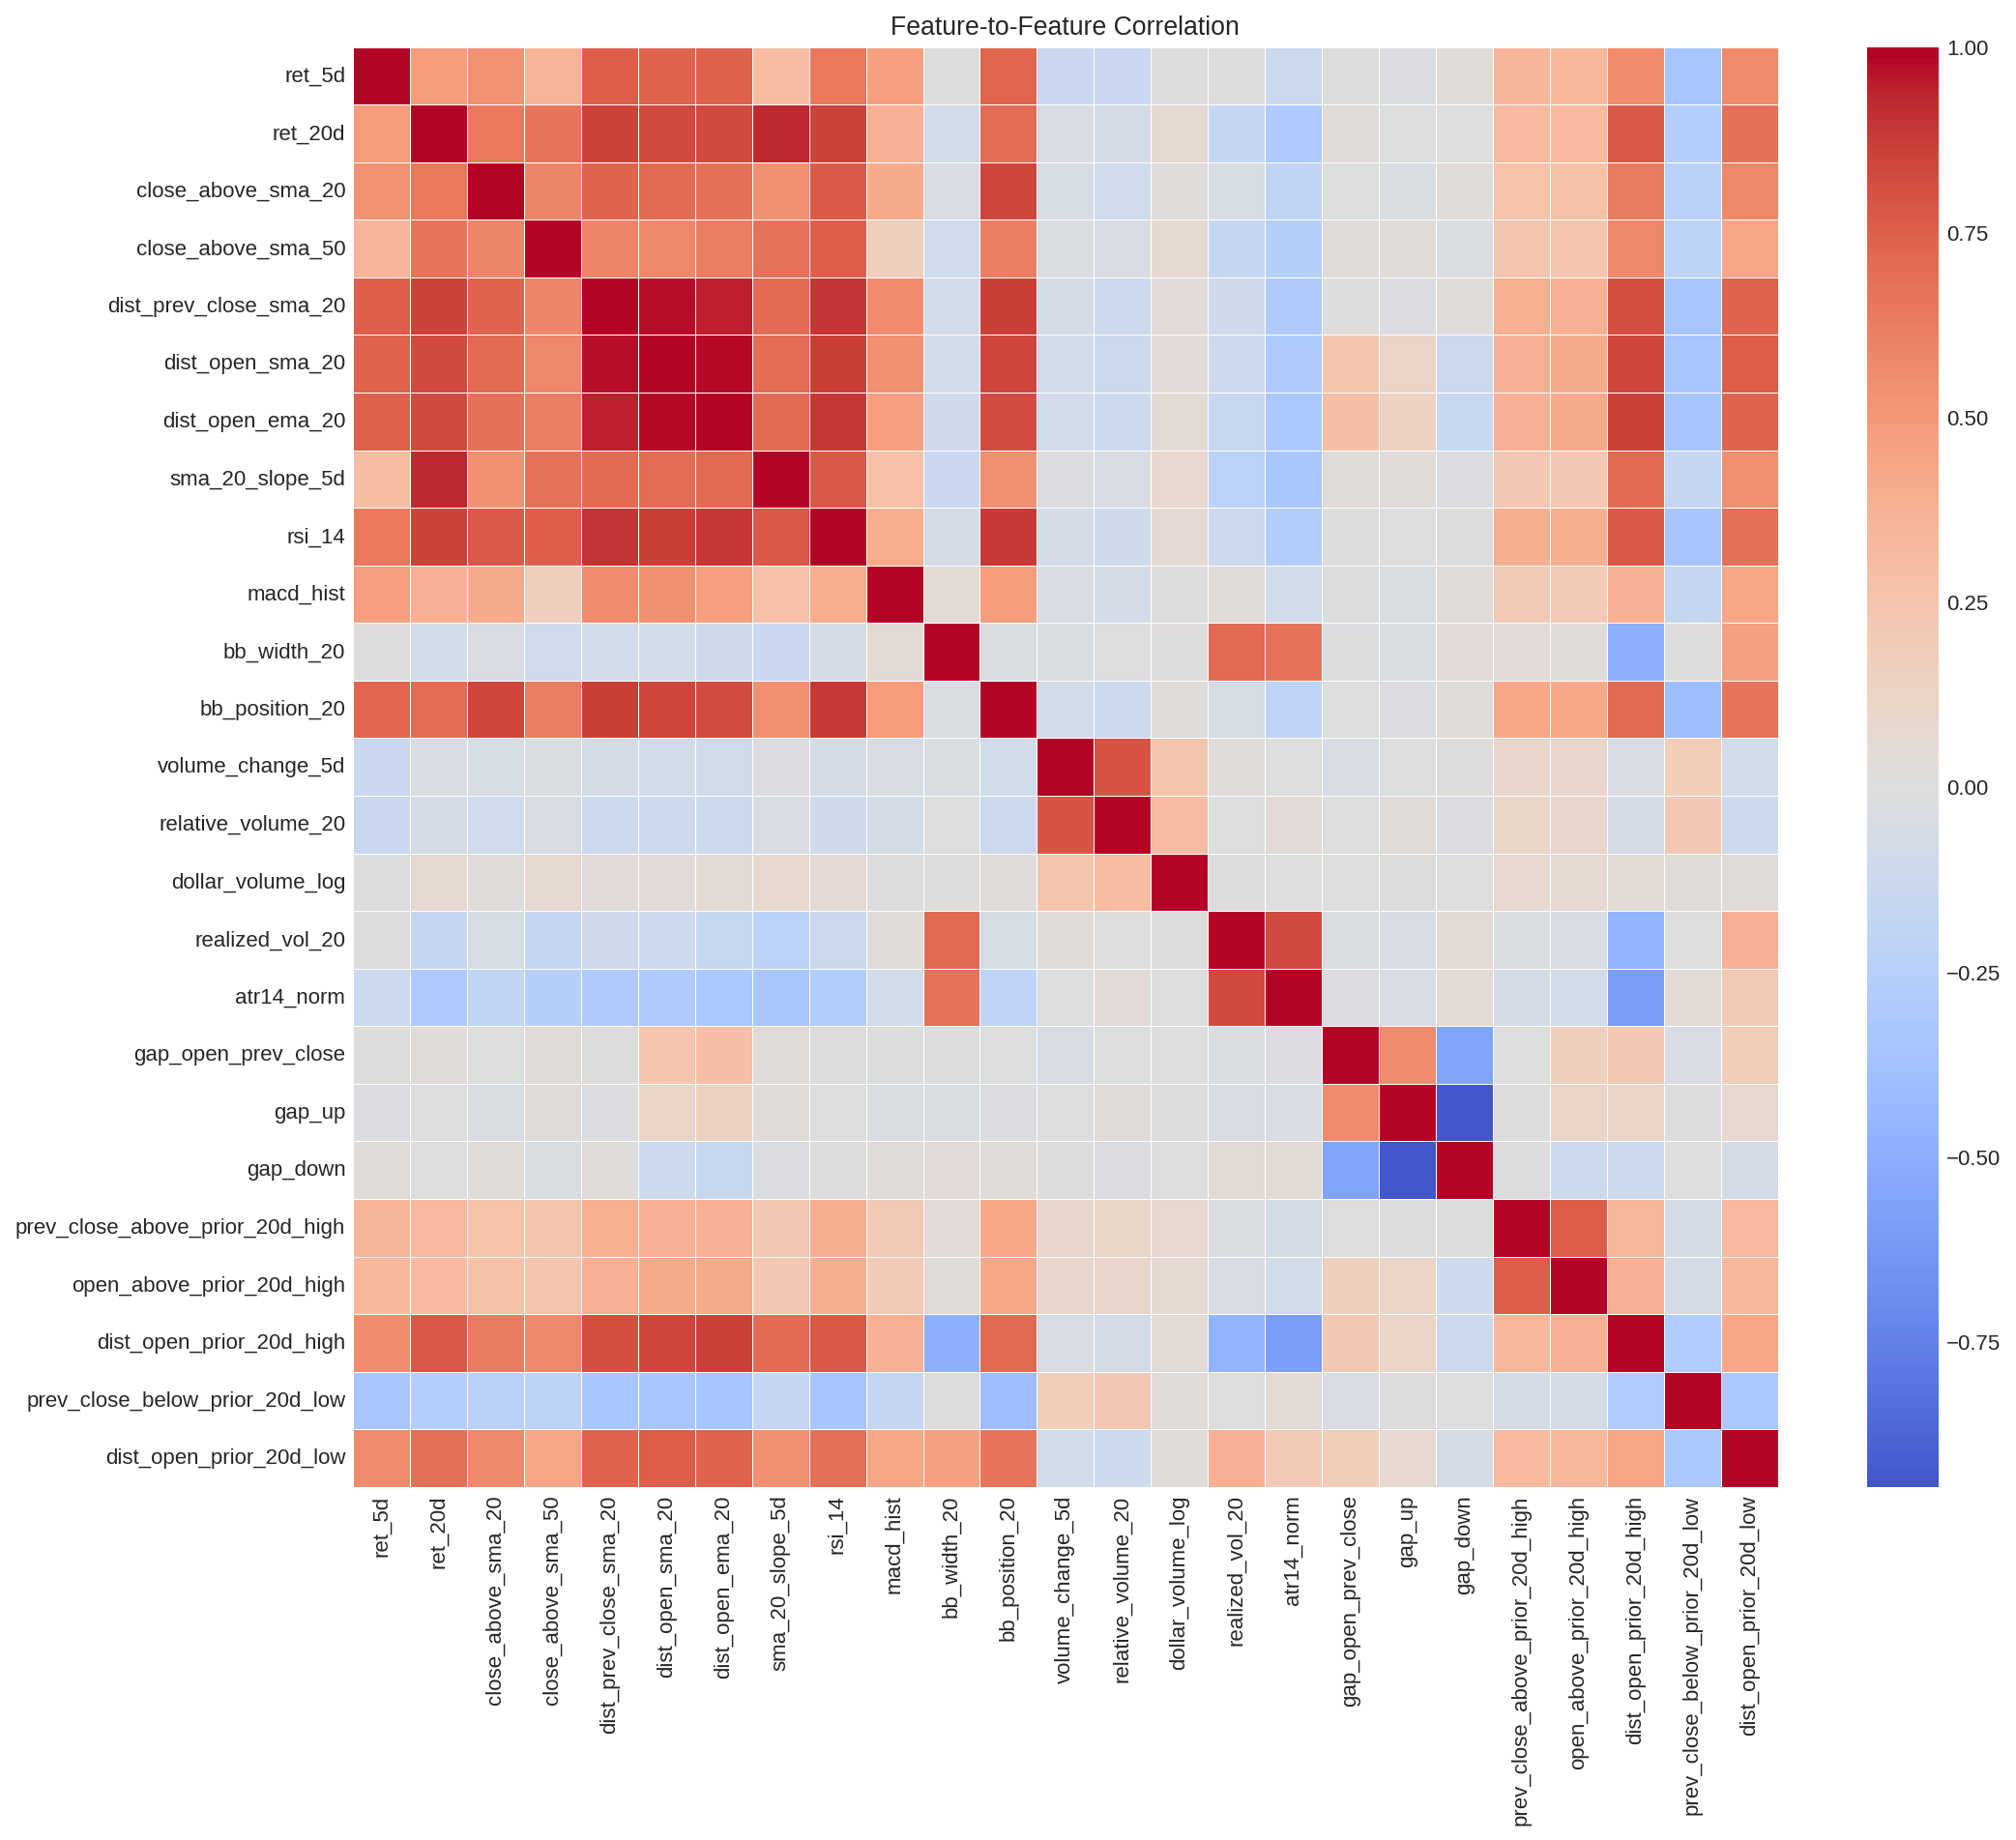

In [21]:
feature_label_corr = feature_label_correlations(analysis_table)
feature_label_corr.to_csv(OUTPUT_DIR / "feature_label_correlations.csv")

feature_label_path = save_heatmap(
    feature_label_corr,
    OUTPUT_DIR / "feature_label_correlation_heatmap.png",
    title="Feature Correlation With Forward Outcomes",
    figsize=(9, 12),
    annot=True,
)
print(f"Saved: {feature_label_path}")
display(Image(filename=str(feature_label_path)))

feature_corr = feature_correlation_matrix(analysis_table)
feature_corr.to_csv(OUTPUT_DIR / "feature_correlation_matrix.csv")
feature_corr_path = save_heatmap(
    feature_corr,
    OUTPUT_DIR / "feature_to_feature_correlation_heatmap.png",
    title="Feature-to-Feature Correlation",
    figsize=(14, 12),
    annot=False,
)
print(f"Saved: {feature_corr_path}")
display(Image(filename=str(feature_corr_path)))


### 6.4 Interpretation Notes

Correlation is exploratory. It can show which indicators historically moved with the label, but it does not prove that future trades will work.


<!-- beginner-explanation -->
**How to read interpretation tables**

- **Top absolute correlations** ranks features by relationship strength with the primary label, regardless of direction.
- A correlation of **0.03** is very weak even if it is at the top of the list.
- **Redundant feature pairs** shows features that mostly tell the same story.
- Distance from SMA 20 and distance from EMA 20 can be highly correlated because both measure distance from a recent average.
- Redundant features are not useless, but they may add less new information.


Top absolute correlations with target_before_stop_5d


,Correlation
prev_close_below_prior_20d_low,-0.029214
ret_5d,0.028638
gap_down,0.025188
gap_up,-0.025144
dist_prev_close_sma_20,0.024659
bb_position_20,0.023073
dist_open_sma_20,0.022625
realized_vol_20,0.020014
macd_hist,0.018649
sma_20_slope_5d,-0.015427


Most redundant feature pairs


,,Correlation
dist_open_sma_20,dist_open_ema_20,0.981989
dist_prev_close_sma_20,dist_open_sma_20,0.970311
gap_up,gap_down,-0.946672
dist_prev_close_sma_20,dist_open_ema_20,0.940997
ret_20d,sma_20_slope_5d,0.929791
dist_prev_close_sma_20,rsi_14,0.894759
dist_open_ema_20,rsi_14,0.887079
rsi_14,bb_position_20,0.880859
dist_open_sma_20,rsi_14,0.868666
dist_prev_close_sma_20,bb_position_20,0.868205


Saved: /scratch/temp_/NN_Trading_Bot_Private/NN_Trading_project/B_Data_Analysis/outputs/top_feature_correlations_target_before_stop.png


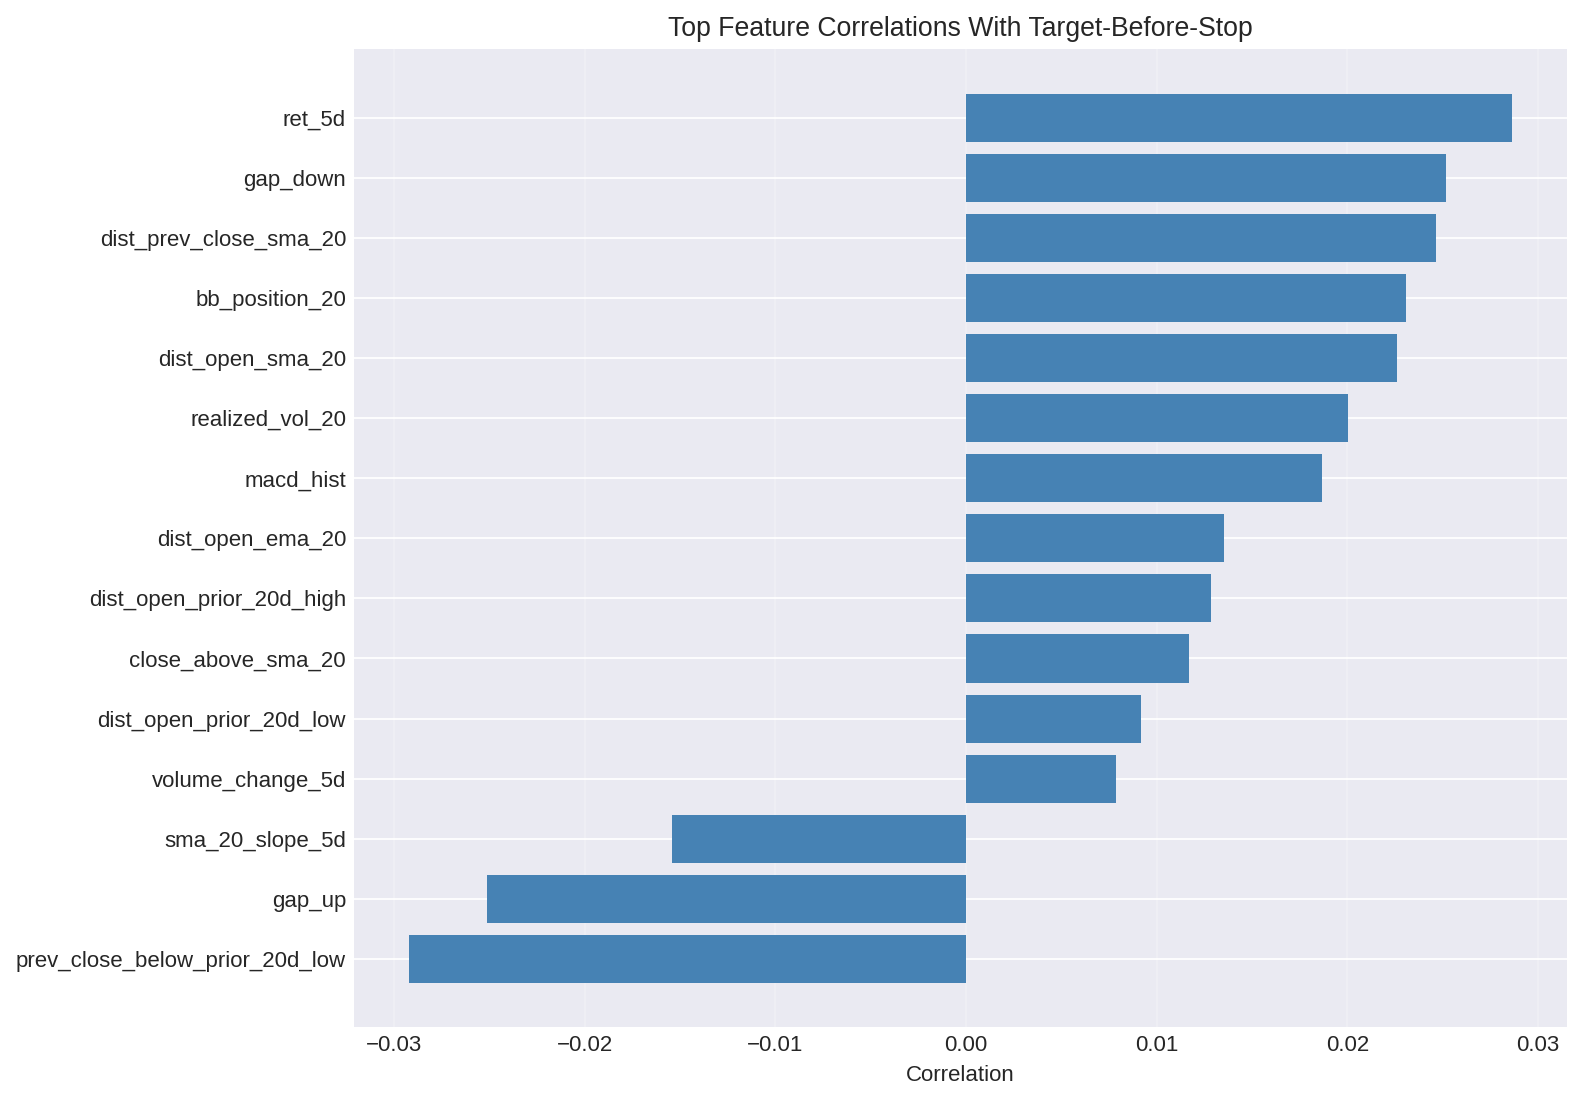

In [22]:
primary_corr = feature_label_corr["target_before_stop_5d"].dropna().sort_values(key=lambda s: s.abs(), ascending=False)
primary_corr_path = save_bar_chart(
    primary_corr.head(15).sort_values(),
    OUTPUT_DIR / "top_feature_correlations_target_before_stop.png",
    title="Top Feature Correlations With Target-Before-Stop",
    ylabel="Correlation",
    horizontal=True,
    figsize=(10, 7),
)

corr_pairs = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool)).stack().rename("Correlation")
redundant_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index).head(15)

print("Top absolute correlations with target_before_stop_5d")
display(primary_corr.head(12).to_frame("Correlation"))
print("Most redundant feature pairs")
display(redundant_pairs.to_frame())
print(f"Saved: {primary_corr_path}")
display(Image(filename=str(primary_corr_path)))


## 7. Expected Outputs

The notebook writes CSV summaries and PNG heatmaps/plots under `B_Data_Analysis/outputs`.


<!-- beginner-explanation -->
**How to read the output inventory**

- This cell lists files saved under **B_Data_Analysis/outputs**.
- CSV files are tables you can open in a spreadsheet.
- PNG files are charts generated by the notebook.
- Rerunning the notebook refreshes these files so the analysis can be inspected outside Jupyter too.


In [23]:
outputs = sorted(OUTPUT_DIR.glob("*"))
print(f"Output files currently present: {len(outputs)}")
for path in outputs:
    print(path.name)


Output files currently present: 40
analysis_feature_table.csv
breakout_outcomes_by_flag_chart.png
breakout_summary_by_flag.csv
breakout_summary_by_sector.csv
dataset_overview.csv
dataset_quality_summary.csv
feature_correlation_matrix.csv
feature_label_correlation_heatmap.png
feature_label_correlations.csv
feature_summary.csv
feature_to_feature_correlation_heatmap.png
forward_outcome_distributions.png
label_prevalence_by_sector.csv
label_prevalence_by_ticker.csv
label_prevalence_by_volatility_bucket.csv
label_prevalence_by_volatility_bucket_chart.png
low_risk_sector_summary.csv
moving_average_trend_examples.png
objective_target_before_stop_pie.png
overall_label_prevalence.csv
sector_correlation_heatmap.png
sector_correlation_matrix.csv
sector_counts.csv
sector_counts_pie.png
sector_mapping_summary.csv
sector_return_risk_summary.csv
sector_success_vs_volatility_scatter.png
sector_ticker_leaders.csv
selected_feature_distributions.png
simple_breakout_examples.png
simple_breakout_feature_su

## 8. Validation Checks Before Further Implementation

These checks guard the analysis assumptions before any future modeling work.


<!-- beginner-explanation -->
**How to read the validation checks**

- These are safety checks for the analysis.
- They confirm that data loaded, labels exist, labels are only **0** or **1**, and features are present.
- They also report missing sector mappings.
- They confirm that **Valid Analysis Window** means **Valid Forward Window** and **Valid Backward Window** are both true.
- Passing validation does not mean the strategy is profitable.
- It only means the analysis workflow ran consistently and did not obviously break the rules defined here.


In [24]:
assert len(stock_data) > 0, "No stock data loaded"
assert not analysis_table.empty, "Analysis table is empty"
assert set(["Ticker", "Sector", "Date"]).issubset(analysis_table.columns)
assert {"valid_forward_window", "valid_backward_window", "valid_analysis_window"}.issubset(analysis_table.columns)
assert analysis_table.loc[analysis_table["valid_forward_window"], "target_before_stop_5d"].notna().all()
assert analysis_table["target_before_stop_5d"].dropna().isin([0.0, 1.0]).all()
assert analysis_table["valid_analysis_window"].equals(analysis_table["valid_forward_window"] & analysis_table["valid_backward_window"])
assert analysis_table.loc[analysis_table["valid_backward_window"], FEATURE_COLUMNS].notna().all().all()
assert len([col for col in FEATURE_COLUMNS if col not in analysis_table.columns]) == 0

missing_sector_count = int((sector_df["Mapping_Status"] != "Mapped").sum())
print("Validation checks passed.")
print(f"Missing sector mappings marked Other: {missing_sector_count}")
print("Model training remains out of scope for this notebook.")


Validation checks passed.
Missing sector mappings marked Other: 0
Model training remains out of scope for this notebook.
